In [3]:
# 导入函数库
import os

os.chdir('/home/xizhang/MRCDFT/MR_CDFT_f90/dataprocessing')
from functionboxes import *


In [4]:
# import matplotlib.pyplot as plt
import os

import pandas as pd

# 设置科研风格绘图参数
plt.rcParams.update({
    'font.size': 12,              # 字体大小
    'font.family': 'serif',       # 字体, 可选:sans-serif, sans-serif, monospace, serif-greek, serif-symbol
    'mathtext.fontset': 'cm',     # 数学字字体，
    'axes.linewidth': 1.5,        # 轴线宽度
    'lines.linewidth': 2,         # 线宽
    'xtick.major.width': 1.5,     # 轴线宽度
    'ytick.major.width': 1.5,     # 轴线宽度
    'xtick.major.size': 6,        # 轴线长度
    'ytick.major.size': 6,        # 轴线长度
    'figure.figsize': [8, 6],     # 图像大小
    'figure.dpi': 100,            # 图像分辨率，
    'savefig.dpi': 300,           # 图片分辨率，
    'savefig.format': 'jpg',      # 图片保存格式
    'savefig.bbox': 'tight'       # 保存图片时自动调整边界
})
class CoreFile:

    def __init__(self, file_name, naming_params, default_value):
        self.file_name = file_name
        self.parameters = naming_parameters

        """
        初始化类实例，批量生成不定属性
        
        :param dir_path: 目标目录路径（字符串）
        :param naming_params: 属性名列表（如["NUC", "Nf"]）
        :param default_value: 所有动态属性的默认值（默认None）
        """
            
        # 关键：批量生成不定属性
        for param_name in naming_params:
            # 用setattr动态添加属性：属性名=param_name，值=default_value
            setattr(self, param_name, default_value)
        
        # （可选）存储命名参数列表，方便后续追溯
        self.naming_components = tuple(naming_params)
        self.df = pd.DataFrame()  
        self.gcm_energy = None

        # 【新增】解析 NUC 属性，生成 A (质量数) 和 Z_sym (元素符号)
        self._parse_nuc()

    def _parse_nuc(self):
        """
        将 NUC 字符串 (如 '40Ca') 拆分为 A (int) 和 symbol (str)
        如果 NUC 尚未赋值或格式不对，则设为 None
        """
        nuc_str = getattr(self, 'NUC', None)
        if nuc_str and isinstance(nuc_str, str):
            # 使用正则表达式匹配开头的数字和后面的字母
            match = re.match(r"(\d+)([a-zA-Z]+)", nuc_str)
            if match:
                self.A = int(match.group(1))      # 质量数，整数类型
                self.sym = match.group(2)       # 元素符号，字符串类型
                # 追加命名参数
                self.naming_components
                # self.naming_components = self.naming_components + (self.A, self.sym)
            else:
                # 如果格式不符合预期（例如只有 'Ca' 没有数字），做容错处理
                self.A = None
                self.sym = nuc_str
                # self.naming_components = self.naming_components + (self.A, self.sym)
        else:
            self.A = None
            self.sym = None
            # self.naming_components = self.naming_components + (self.A, self.sym)

    def update_param(self, param_name, new_value):
        """更新指定动态属性的值（带存在性校验）"""
        if not hasattr(self, param_name):
            raise AttributeError(f"实例无此属性：{param_name}（请检查naming_parameters）")
        setattr(self, param_name, new_value)

        # 【重要】如果更新的是 NUC，需要重新解析 A 和 Z_sym
        if param_name == 'NUC':
            self._parse_nuc()

    def getdata(self, df):
        self.df = df

    def get_all_params(self):
        """获取所有动态属性的键值对（返回字典）"""
        return {name: getattr(self, name) for name in self.naming_components}

    def __str__(self):
        """面向用户的友好显示：简洁关键信息"""
        namelist = []
        for name in self.naming_components:
            str = f"   {name}: {getattr(self, name)!r},\n"
            namelist.append(str)
        # 形成字符串
        namestr = "".join(namelist)
        return (
            f"CoreFile(\n"
            f"{namestr}"
            # f"  dir_path={self.dir!r},\n"
            # f"  naming_params={self.naming_components!r},\n"
            # f"  default_value={getattr(self, self.naming_components[0], None)!r}\n"
            f")"
        )
    
    def __repr__(self):
        """面向开发者的精确描述：可复现的实例信息"""
        namelist = []
        for name in self.naming_components:
            str = f"   {name}: {getattr(self, name)!r},\n"
            namelist.append(str)
        # 形成字符串
        namestr = "".join(namelist)
        return (
            f"CoreFile(\n"
            f"{namestr}"
            # f"  dir_path={self.dir!r},\n"
            # f"  naming_params={self.naming_components!r},\n"
            # f"  default_value={getattr(self, self.naming_components[0], None)!r}\n"
            f")"
        )
    


class CoreFilesManager:

    def __init__(self, pdir, naming_params):
        self.pdir = pdir
        self.parameters = naming_params
        self.cores_list = []
        for dir in os.listdir(pdir):
            # print(f"Processing file: {dir}")
            # print(dir)
            # print(os.listdir(dir))
            for file in os.listdir(pdir+dir):
                # print(pdir+dir)
                # print(self.process_file(file))
                self.cores_list.append(self.process_file(file, pdir+dir))
        self.classified_params_dir={}
        self.classify_params1()

    def _parse_nuc(self, NUC):
        """
        将 NUC 字符串 (如 '40Ca') 拆分为 A (int) 和 symbol (str)
        如果 NUC 尚未赋值或格式不对，则设为 None
        """
        
        if NUC and isinstance(NUC, str):
            # 使用正则表达式匹配开头的数字和后面的字母
            match = re.match(r"(\d+)([a-zA-Z]+)", NUC)
            if match:
                return int(match.group(1)), match.group(2)       # 元素符号，字符串类型
                
            else:
                # 如果格式不符合预期（例如只有 'Ca' 没有数字），做容错处理
                return None, NUC
                
        else:
            return None, None

    def process_file(self, file, path):
        dynamic_params, _ = self.split_file_name(file)
        # print(dynamic_params)
        dynamic_params['A'], dynamic_params['sym'] = self._parse_nuc(dynamic_params['NUC'])
        
        core_file = CoreFile(file, dynamic_params, None)
        # /home/xizhang/MRCDFT/MR_CDFT_f90/datas/40Ca/40Ca_6_11_2026-03-31-21-32-20/results/kern_data.csv
        core_file.getdata(pd.read_csv(f'{path}/{file}/results/kern_data.csv'))
        if os.path.exists(f'{path}/{file}/exec/energy.txt'):
            with open(f'{path}/{file}/exec/energy.txt', 'r') as f:
                num_str = f.read().strip()  # 去除首尾空格/换行
                num = float(num_str)  # 先转为浮点数
                # num_int = int(num_float)    # 再转为整数（直接截断小数部分）
                # print(num)  # 输出：-344
                core_file.gcm_energy = num  
        # print(core_file.df)
        for key, value in dynamic_params.items():
            core_file.update_param(key, value)
            # print(f"{key}: {value}")
        return core_file

    # 根据不同属性进行归类，结构应该是这样的
    """
    self.classified_params = {
        param1:{
            value1: [core_file1, core_file2, ...],
            value2: [core_file3, core_file4, ...],
            ...
        },
        param2:{
            value1: [core_file5, core_file6, ...],
            value2: [core_file7, core_file8, ...],
            ...
        },
        ...

        }
        }
    """
    def classify_params(self):
        
        
        for param_name in self.parameters:
            for core_file in self.cores_list:
                param_value = getattr(core_file, param_name)
                # print(param_name, param_value)
                if param_name not in self.classified_params_dir:
                    # print(param_name, self.classified_params_dir)
                    self.classified_params_dir[param_name] = {}
                    if param_value in self.classified_params_dir[param_name].keys():
                        # print(self.classified_params_dir)
                        self.classified_params_dir[param_name][param_value].append(core_file)
                    else:
                        
                        self.classified_params_dir[param_name] = {}
                        self.classified_params_dir[param_name][param_value] = [core_file]
                else:  
                    if param_value in self.classified_params_dir[param_name].keys():
                        self.classified_params_dir[param_name][param_value].append(core_file)
                    else:
                        
                        self.classified_params_dir[param_name] = {}
                        self.classified_params_dir[param_name][param_value] = [core_file]
                        

        # return {}
    def classify_params1(self):
        # 初始化分类字典（若为空）
        if not hasattr(self, 'classified_params_dir'):
            self.classified_params_dir = {}
        # print(self.parameters)
        if 'A' not in self.parameters:
            self.parameters.append('A')
        if 'sym' not in self.parameters:
            self.parameters.append('sym')
        for param_name in self.parameters:
            # 1. 为该参数初始化字典（仅首次处理时）
            if param_name not in self.classified_params_dir:
                self.classified_params_dir[param_name] = {}
            
            # 2. 遍历所有CoreFile，按参数值归类
            for core_file in self.cores_list:
                param_value = getattr(core_file, param_name)
                
                # 3. 若参数值未收录，创建新列表；否则追加到现有列表
                if param_value not in self.classified_params_dir[param_name]:
                    self.classified_params_dir[param_name][param_value] = []
                self.classified_params_dir[param_name][param_value].append(core_file)
            
            for param_name, value_dict in self.classified_params_dir.items():
                # 遍历该参数下的每个具体值 (如 'NUC' 下的 '40Ca', '42Ca'...)
                for key, core_list in value_dict.items():
                    
                    # 定义排序规则：
                    # 1. 优先按质量数 A (int) 升序
                    # 2. 其次按元素符号 sym (str) 字母序
                    # 3. 最后按 Nf (转为 int) 升序
                    # 这样无论我是按 NUC 分组还是按 A 分组，组内都是有序的物理序列
                    core_list.sort(key=lambda c: (
                        c.A if c.A is not None else 9999,
                        c.sym if c.sym is not None else "zzz",
                        int(c.Nf) if c.Nf and str(c.Nf).isdigit() else 9999
                    ))

            
            


    def split_file_name(self, file_name):
        """将文件名拆分为动态属性"""
        
        file_name_parts = file_name.split("_")
        dynamic_params = {param: file_name_parts[i] for i, param in enumerate(self.parameters)}
        static_params = file_name_parts[len(self.parameters):]
        return dynamic_params, static_params

naming_parameters = ["NUC", "Nf", "PA", "time"]
cfm = CoreFilesManager("/home/xizhang/MRCDFT/MR_CDFT_f90/datas/", naming_parameters)
# print(cfm.parameters)
# cfm.split_file_name("40Ca_6_11_2026-03-31-21-32-20")
# print(cfm.cores_list)
print(cfm.classified_params_dir['A'][40],len(cfm.classified_params_dir['A'][40]))

[CoreFile(
   NUC: '40Ca',
   Nf: '6',
   PA: '11',
   time: '2026-03-31-21-32-20',
   A: 40,
   sym: 'Ca',
), CoreFile(
   NUC: '40Ca',
   Nf: '8',
   PA: '11',
   time: '2026-04-11-21-23-31',
   A: 40,
   sym: 'Ca',
), CoreFile(
   NUC: '40Ca',
   Nf: '10',
   PA: '11',
   time: '2026-04-12-19-34-21',
   A: 40,
   sym: 'Ca',
), CoreFile(
   NUC: '40Ca',
   Nf: '12',
   PA: '11',
   time: '2026-04-18-15-59-07',
   A: 40,
   sym: 'Ca',
), CoreFile(
   NUC: '40Ca',
   Nf: '14',
   PA: '11',
   time: '2026-04-18-15-58-15',
   A: 40,
   sym: 'Ca',
)] 5


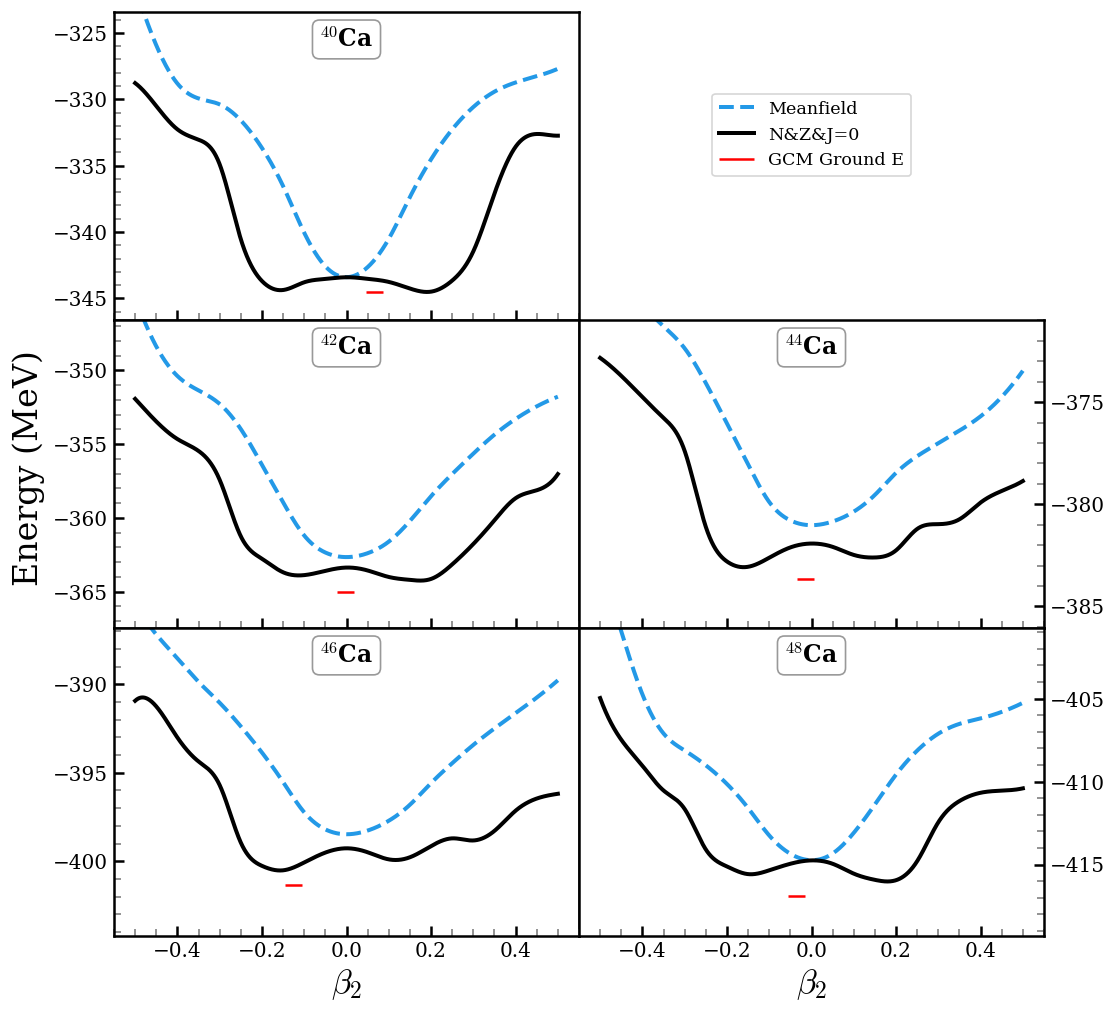

In [ ]:
from scipy.interpolate import interp1d
class DataProcessingandPlot():
    def __init__(
            self, cores, num, delete_num, palettes, 
            y_columns=['Etot', 'energy_J0', 'energy_J2', 'energy_J4', 'energy_J6'],
            labels=['Meanfield', 'N&Z&J=0', 'N&Z&J=2', 'N&Z&J=4', 'N&Z&J=6', 'GCM_energy'],
            inter_method='cubic',
            xlabel=r"$\beta_2$",
            ylabel="Energy (MeV)",
            title="Isotope chain of Ca with different J",
            ticks=None, ranges=None):
        self.cores = cores
        self.delete_num = delete_num
        # print(list(self.cores.keys())[num])
        self.df_origin = self.cores[1].df
        self.y_columns = y_columns
        self.kind = inter_method  # 使用线性插值linear，更稳定, cubic更平滑, 
        self.num_points = 10000  # 统一插值点数
        self.palettes = palettes
        self.labels    = labels
        self.xlabel   = xlabel
        self.ylabel    = ylabel
        self.title     = title
        # 刻度
        self.ticks = ticks
        self.ranges = ranges

    def interpolated_data(self, df_origin):
            

        
        # df_copy = final_df.copy()

        # 将beta2=0的行对应的列energy_J2,4,6设为NAN
        df_origin.loc[(df_origin['beta2'] >= -self.delete_num) & (df_origin['beta2'] <= self.delete_num), ['energy_J2', 'energy_J4', 'energy_J6']] = np.nan
        # print(df_copy)


        # 获取数据
        df = df_origin.copy()
        # print(df)
        x = df['beta2'].values.astype(float)

        # 设置插值参数
        


        # 创建统一的插值网格
        x_uniform = np.linspace(x.min(), x.max(), self.num_points)

        # 存储插值结果
        interpolated_data = {'beta2': x_uniform}

        # 处理每个列
        for col in self.y_columns:
            y_data = df[col].values.astype(float)
            
            # 创建非NaN掩码
            mask = ~np.isnan(y_data)
            
            # 找到连续非NaN段的边界
            diff = np.diff(mask.astype(int))
            split_indices = np.where(diff != 0)[0] + 1
            
            # 初始化插值结果数组
            y_interp = np.full(self.num_points, np.nan)
            
            # 处理每个分段
            start_indices = [0] + split_indices.tolist()
            end_indices = split_indices.tolist() + [len(y_data)]
            
            for s, e in zip(start_indices, end_indices):
                if s >= e:
                    continue
                    
                seg_x = x[s:e]
                seg_y = y_data[s:e]
                if np.all(np.isnan(seg_y)):
                    continue
                
                # 单点段直接赋值
                if len(seg_x) == 1:
                    idx = np.argmin(np.abs(x_uniform - seg_x[0]))
                    y_interp[idx] = seg_y[0]
                    continue
                    
                # 创建插值函数
                f = interp1d(seg_x, seg_y, kind=self.kind, bounds_error=False, fill_value=np.nan)
                
                # 在当前分段范围内插值
                segment_mask = (x_uniform >= seg_x.min()) & (x_uniform <= seg_x.max())
                y_interp[segment_mask] = f(x_uniform[segment_mask])
            
            # 存储插值结果
            interpolated_data[col] = y_interp
        return interpolated_data
    
    def plot_package(self, text, figsize):

        interpolated_data = self.interpolated_data(self.df_origin)
        # 创建插值后的DataFrame
        final_df = pd.DataFrame(interpolated_data)

        df_origin = self.df_origin.copy()
        df_copy = final_df.copy()

        x = df_copy['beta2'].values.astype(float)
        # y_columns = ['Etot', 'energy_J0', 'energy_J2', 'energy_J4', 'energy_J6']

        # save_path_plus = f"{save_path}/{name}_positive_beta2_energy_curve.png"

        # 绘图，beta2作为x轴，Etot，energy_J0, energy_J2,energy_J4,energy_J6作为y轴, 绘制于同一附图中。颜色和线条配置采用palettes.group6和palettes.linestyles
        plt.rcParams['text.usetex'] = True
        plt.rcParams['font.family'] = 'serif'

        # 假设你的数据框是 merged_nodio_plus
        merged = df_copy.copy()   # 建议 copy 避免 SettingWithCopyWarning

        # 颜色 / 线型
        # 1. 决定总共几条线、哪些要重点突出
        total_lines = 5
        highlight = [1]          # 第0条和第2条要最显眼（从0开始数）

        # 2. 自动获取颜色和线型（默认用蓝色系）
        colors, linestyles = palettes.auto_for_lines(
            total_lines=total_lines,
            highlight_indices=highlight,
            prefer_hue="red"       # 可以改成 "green"、"red"、"purple" 等
        )

        # colors = palettes.nature5

        # linestyles = palettes.linestyles

        fontsize = 24
        # 不加粗
        fontweight = "normal"
        # fontweight = "bold" # 不加粗单词  加粗    斜体

        plt.figure(figsize=figsize, dpi=120)
        # 遍历每条曲线
        for i, y_col in enumerate(self.y_columns):
                # 获取当前列的数值数据（注意转换为 float 避免类型错误）
                y_data = merged[y_col].astype(float).values
                # print(type(merged))
                # 绘制平滑曲线（如果需要插值）
                plt.plot(x, y_data,
                        color=colors[i % len(colors)],
                        linestyle=linestyles[i % len(linestyles)],
                        linewidth=2.4,
                        alpha=0.95,
                        label=self.labels[i])
                # print(type(df_origin))



        plt.ylabel(self.ylabel, fontsize=fontsize, fontweight=fontweight)
        plt.xlabel(self.xlabel, fontsize=fontsize, fontweight=fontweight)
        plt.title(self.title, fontsize=fontsize, fontweight=fontweight, pad=15)

        

        plt.legend(fontsize=13, loc='best', frameon=True, shadow=True, fancybox=True)

        if text:
            plt.annotate(text, 
                xy=(0.5, 0.95), xycoords='axes fraction',
                ha='center', va='top', fontsize=14, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.8))

        # 黑色强调实验值（如果你有实验点，可在这里额外画）
        # plt.scatter(beta2_exp, Etot_exp, color='red', s=80, marker='*', zorder=20, label='Exp.')
        # print(colors)
        plt.tight_layout()

    def plot_multiple_subplots(self, num_rows:int=3, num_cols:int=3, figsize=(10, 10), 
                               sub_ax_locations_list=[(0, 0), 
                                                    (1, 0), (1, 1),
                                                    (2, 0), (2, 1)]):
        """
        num_rows: int, number of rows in the grid
        num_cols: int, number of columns in the grid
        figsize: tuple, size of the figure
        sub_ax_locations_list: list[tuples],list of tuples, each tuple represents the location of a subplot in the grid
        """
        # 创建子图网格
        fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize, dpi=120)
        axes[0, 1].axis('off')
        # print(type(axes[1][1]))
        # 确保axes 是一个二维数组
        if num_rows == 1 and num_cols == 1:
            axes = np.array([[axes]])
        elif num_rows == 1:
            # 将一维数组转换为二维数组，通过reshape方法实现， -1表示自动计算列数
            axes = axes.reshape(1, -1)
        elif num_cols == 1:
            axes = axes.reshape(-1, 1)
        
        # 第一列子图共享x轴
        for ax in axes[:, 0]:
            ax.sharex(axes[0, 0])
        
        # 第二列子图共享x轴
        for ax in axes[:, 1][:2]:
            ax.sharex(axes[0, 1])
        
        # ---------------------- 3. 调整子图间距（紧密相邻） ----------------------
        fig.subplots_adjust(
            hspace=0,   # 垂直方向无间距
            wspace=0 # 水平方向留极小间距（避免线条重叠，可根据需求调整）
        )  
        
        # ---------------------- 4. 控制y轴分辨率（刻度数量） ----------------------
        
        for ax in axes.flatten():  # 遍历所有子图（含隐藏的，需判断是否可见）
            
            if ax.get_visible():  # 仅处理可见子图

                # 限制y轴显示5个刻度（自动计算间隔，数值越小分辨率越高）
                ax.tick_params(axis='both', direction='in')
                ax.tick_params(
                                axis='both',
                                which='minor',    # 只改辅刻度
                                direction='in',   # 辅刻度也朝内
                                length=4,        # 辅刻度线更短（默认比主刻度短）
                                width=1,          # 辅刻度线更细
                                colors='gray'     # 辅刻度线颜色（可选，弱化视觉）
                            )
                import matplotlib.ticker as ticker
                # ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(n=5))
                # ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(n=5))
                
                # ax.locator_params(axis='y', nbins=6) 
        # ---------------------- 5. 右列y轴标签居右 ----------------------
        for i in range(3):  # 遍历右列（列索引j=1）的所有行
            ax = axes[i, 1]
            ax.yaxis.set_label_position("right")  # 将y轴标签移到右侧
            ax.tick_params(axis='y', which='both', left=False, right=True, labelleft=False, labelright=True)  # 刻度标签也显示在右侧
            # ax.tick_params(axis='y', which='both', direction='in')


        # 遍历每个子图
        for idx, core in enumerate(self.cores):
            

            row, col = sub_ax_locations_list[idx]
            # 声明row, col的类型
            row, col = int(row), int(col)
            ax = axes[row, col]

                              
            # 获取当前子图的数据
            # original_df = core.df.copy()
            interpolated_data = self.interpolated_data(core.df.copy())
            gcm_energy = core.gcm_energy
            finally_df = pd.DataFrame(interpolated_data)
            if self.ranges:
                
                max_y, min_y = self.ranges[idx]
            else:
                max_y = max(list(finally_df[self.y_columns].max()))
                min_y = min(list(finally_df[self.y_columns].min()))

            # 直接设置 y 轴范围（留一点上下边距）
            margin = (max_y - min_y) * 0.08          # 8% 边距，可调小到 0.05 或 0.1
            ax.set_ylim(min_y - margin, max_y + margin) # 设置 y 轴范围, 第一个参数控制

            # 让 matplotlib 自动决定刻度数量和位置（通常很美观）
            ax.locator_params(axis='y', nbins=5)     # 目标显示约6个主刻度，可改成5~8
            # print(max_y, min_y, engraving_degree)
            # ax.locator_params(axis='y', nbins=engraving_degree)
            ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(n=4))
            ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(n=5))
            # print(interpolated_data)

            # 1. 决定总共几条线、哪些要重点突出
            # total_lines = 5
            highlight = [1]          # 第1条要最显眼（从0开始数）
            sub_highlight = [0]


            colors, linestyles = palettes.get_all_colors_linestyles(
                                                    total=len(self.y_columns),
                                                    emphasize_indices=highlight,
                                                    sub_emphasize_indices=sub_highlight   # 可以为空
                                                )


            # 绘制插值曲线
            x = finally_df['beta2'].values.astype(float)
            # print(self.palettes.nature5,'\n', colors)
            for i, y_col in enumerate(self.y_columns):
                y_data = finally_df[y_col].astype(float).values
                
                ax.plot(x, y_data,
                        color=colors[i % len(colors)],
                        linestyle=linestyles[i % len(linestyles)],
                        linewidth=2.4,
                        alpha=1,
                        label=self.labels[i]
                        )
            # print(self.cores)
            # print(idx, self.cores[idx].NUC)
            ax.annotate(f"$^{{{self.cores[idx].NUC[0:2]}}}${self.cores[idx].NUC[2:4]}", 
                xy=(0.5, 0.95), xycoords='axes fraction',
                ha='center', va='top', fontsize=14, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.8), zorder=200)
            # # 假设你想在 beta2 = 0.0 处标注这个值
            # x_pos = beta2_expectation[idx]          # 你想放短线的位置
            # marked_value = gcm_energy
            # half_length = 0.02   # 短线左右各延伸多少（单位是 beta2）


            # ax.plot(
            #     [x_pos - half_length, x_pos + half_length], 
            #     [marked_value, marked_value],
            #     color='red',
            #     linewidth=1.5,
            #     solid_capstyle='butt',   # 让线端平直，更像 hlines
            #     label=f'GCM Ground E'   # ← 这里给 label 就行了
            # )
            
            # 8. 添加图例（只在某一个子图显示）
            if row == 1 and col == 1:
                ax.legend(
                fontsize=10.5,
                loc='center',
                # ncol=5,                    # 横向排列
                frameon=True,
                fancybox=True,
                shadow=False,
                bbox_to_anchor=(0.5, 1.6),  # 稍微向上一点，避免太贴底
            )
            
            if row == 2:
                # 设置x坐标，标题
                ax.set_xlabel(self.xlabel, fontsize=20, fontweight='normal')

            

        fontweight = "normal"        
        # 11. 添加全局标题和标签
        # fig.suptitle(self.title, fontsize=20, fontweight=fontweight, y=0.92) # y参数调整标题位置
        # fig.supxlabel(self.xlabel, fontsize=20, fontweight=fontweight, y=0.05)
        fig.supylabel(self.ylabel, fontsize=20, fontweight=fontweight, x=0.04)

        # 13. 调整布局
        # plt.tight_layout(rect=[0, 0, 1, 0.98]) # 为全局标题留空间

ticks = [
    [325, 330, 335, 340, 345],
    [348, 352, 356, 360, 364],
    [362, 368, 374, 380, 386],
    [388, 391, 394, 397, 400],
    [400, 404, 408, 412, 416]
]       
ranges = [
    (-325, -345),
    (-348, -366),
    (-372, -385),
    (-388, -403),
    (-402, -418)
]         
sub_ax_locations = [
(0, 0), 
(1, 0), (1, 1),
(2, 0), (2, 1)
]
y_columns=['Etot', 'energy_J0']
labels=['Meanfield', 'N&Z&J=0', 'GCM_energy']
inter_method='cubic'
xlabel=r"$\beta_2$"
ylabel="Energy (MeV)"
title="Isotope chain of Ca with different J"
palettes = TopJournalPalettes()
# 删除掉第二个元素
# if len(cores) > 5:
#     cores.pop(list(cores.keys())[1])
# print(cores['42Ca'].df)
# cores = cores_dict["11"]
dfs = cfm.classified_params_dir['Nf']["6"]
# print(cores)
corelist = []
for core in dfs:
    corelist.append(core.NUC)
    # 排序
    corelist = sorted(corelist)
# print(corelist)

corees = []
for num in corelist:
    for core in dfs:
        if core.NUC == num:
            
            corees.append(core)
# print(corees)
# cores = core_dict
beta2_expectation = [0.0658, -0.0031, -0.0147, -0.1244, -0.0362]
dpap = DataProcessingandPlot(corees, 1, 0.1, palettes, ticks=None, ranges=ranges, y_columns=y_columns, labels=labels, inter_method=inter_method, xlabel=xlabel, ylabel=ylabel, title=title)
dpap.plot_multiple_subplots(num_rows=3, num_cols=2, sub_ax_locations_list=sub_ax_locations)


In [ ]:
# 重构数据库
cores = cfm.classified_params_dir['NUC']["40Ca"]
# print(cores)
# 重构数据库 - 正确的合并方式

def merge_df(key='Etot'):
    df_temp = None
    for core in cfm.classified_params_dir['NUC']["40Ca"]:
        temp_df = core.df[['beta2', 'beta3', key]].rename(columns={key: f'{key}_{core.Nf}'})
        if df_temp is None:
            df_temp = temp_df
        else:
            df_temp = pd.merge(df_temp, temp_df, on=['beta2', 'beta3'], how='outer')
    # print(df_temp)
    return df_temp
 
dfs = [merge_df('Etot')]
dfs.append(merge_df('energy_J0'))
print(dfs)

['6', '6', '6', '6', '6']
[CoreFile(
   NUC: '40Ca',
   Nf: '6',
   PA: '11',
   time: '2026-03-31-21-32-20',
   A: 40,
   sym: 'Ca',
), CoreFile(
   NUC: '42Ca',
   Nf: '6',
   PA: '11',
   time: '2026-03-31-21-32-35',
   A: 42,
   sym: 'Ca',
), CoreFile(
   NUC: '44Ca',
   Nf: '6',
   PA: '11',
   time: '2026-03-31-21-32-26',
   A: 44,
   sym: 'Ca',
), CoreFile(
   NUC: '46Ca',
   Nf: '6',
   PA: '11',
   time: '2026-03-31-21-32-47',
   A: 46,
   sym: 'Ca',
), CoreFile(
   NUC: '48Ca',
   Nf: '6',
   PA: '11',
   time: '2026-03-31-21-32-47',
   A: 48,
   sym: 'Ca',
), CoreFile(
   NUC: '40Ca',
   Nf: '6',
   PA: '11',
   time: '2026-03-31-21-32-20',
   A: 40,
   sym: 'Ca',
), CoreFile(
   NUC: '42Ca',
   Nf: '6',
   PA: '11',
   time: '2026-03-31-21-32-35',
   A: 42,
   sym: 'Ca',
), CoreFile(
   NUC: '44Ca',
   Nf: '6',
   PA: '11',
   time: '2026-03-31-21-32-26',
   A: 44,
   sym: 'Ca',
), CoreFile(
   NUC: '46Ca',
   Nf: '6',
   PA: '11',
   time: '2026-03-31-21-32-47',
   A: 46,


IndexError: list index out of range

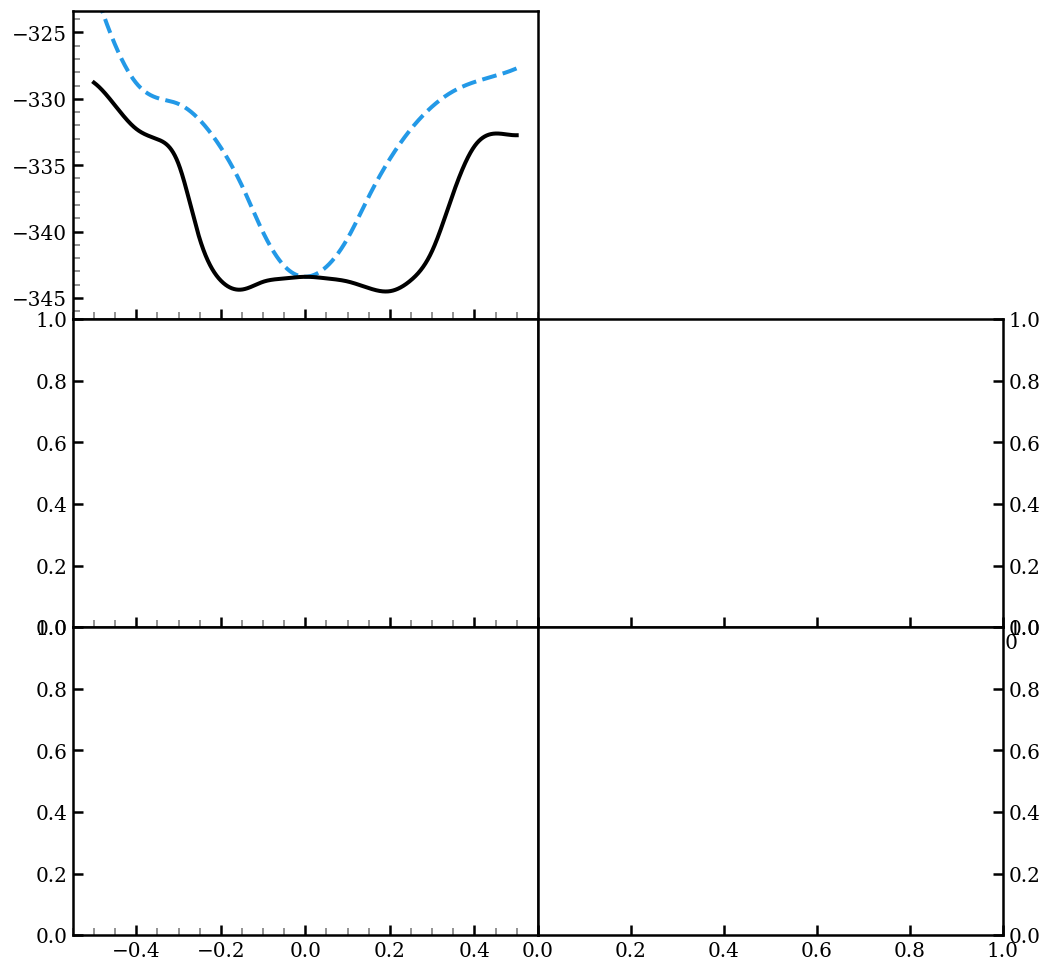

In [8]:

ticks = [
    [325, 330, 335, 340, 345],
    [348, 352, 356, 360, 364],
    [362, 368, 374, 380, 386],
    [388, 391, 394, 397, 400],
    [400, 404, 408, 412, 416]
]       
ranges = [
    (-325, -345),
    (-348, -366),
    (-372, -385),
    (-388, -403),
    (-402, -418)
]         
sub_ax_locations = [
(0, 0), 
(1, 0), (1, 1),
(2, 0), (2, 1)
]
y_columns=['Etot', 'energy_J0']
labels=['Meanfield', 'N&Z&J=0', 'GCM_energy']
inter_method='cubic'
xlabel=r"$\beta_2$"
ylabel="Energy (MeV)"
title="Isotope chain of Ca with different J"
palettes = TopJournalPalettes()
# 删除掉第二个元素
# if len(cores) > 5:
#     cores.pop(list(cores.keys())[1])
# print(cores['42Ca'].df)
# cores = cores_dict["11"]
dfs = cfm.classified_params_dir['Nf']["6"]
# print(cores)
corelist = []
for core in dfs:
    corelist.append(core.Nf)
    # 排序
    corelist = sorted(corelist)
print(corelist)

corees = []
for num in corelist:
    for core in dfs:
        if core.Nf == num:
            
            corees.append(core)
print(corees)
# # cores = core_dict
# beta2_expectation = [0.0658, -0.0031, -0.0147, -0.1244, -0.0362]
dpap = DataProcessingandPlot(corees, 1, 0.1, palettes, ticks=None, ranges=ranges, y_columns=y_columns, labels=labels, inter_method=inter_method, xlabel=xlabel, ylabel=ylabel, title=title)
dpap.plot_multiple_subplots(num_rows=3, num_cols=2, sub_ax_locations_list=sub_ax_locations)


['Nf=6', 'Nf=8', 'Nf=10', 'Nf=12', 'Nf=14']


KeyError: 'Etot_6'

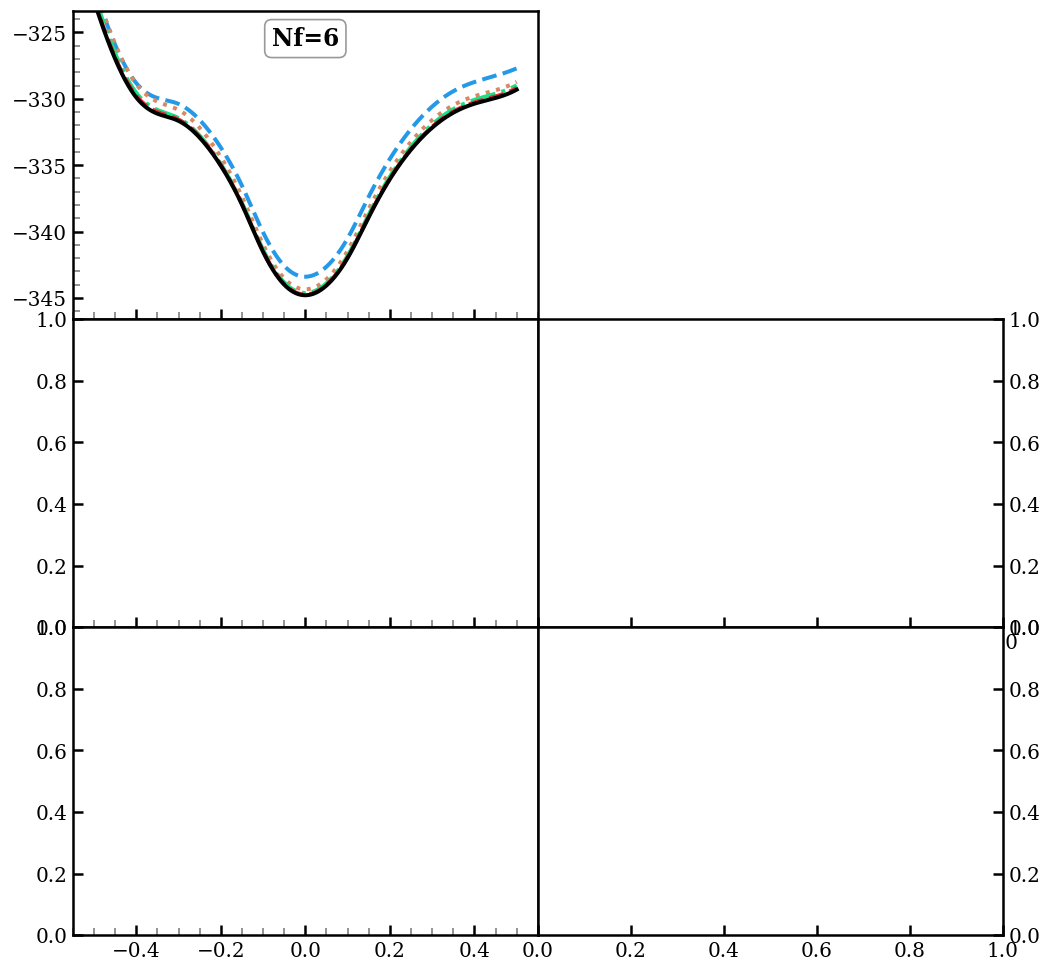

In [17]:
from scipy.interpolate import interp1d
class DataProcessingandPlot():
    def __init__(
            self, dfs, num, delete_num, palettes, 
            y_columns=['Etot', 'energy_J0', 'energy_J2', 'energy_J4', 'energy_J6'],
            labels=['Meanfield', 'N&Z&J=0', 'N&Z&J=2', 'N&Z&J=4', 'N&Z&J=6', 'GCM_energy'],
            inter_method='cubic',
            xlabel=r"$\beta_2$",
            ylabel="Energy (MeV)",
            subtitles=[],
            title="Isotope chain of Ca with different J",
            ticks=None, ranges=None):
        self.dfs = dfs
        self.delete_num = delete_num
        # print(list(self.cores.keys())[num])
        self.df_origin = self.dfs[1]
        self.y_columns = y_columns
        self.kind = inter_method  # 使用线性插值linear，更稳定, cubic更平滑, 
        self.num_points = 10000  # 统一插值点数
        self.palettes = palettes
        self.labels    = labels
        self.xlabel   = xlabel
        self.ylabel    = ylabel
        # 子图标题
        self.subtitles = subtitles
        self.title     = title
        # 刻度
        self.ticks = ticks
        self.ranges = ranges

    def interpolated_data(self, df_origin):
            

        
        # df_copy = final_df.copy()

        # 将beta2=0的行对应的列energy_J2,4,6设为NAN
        df_origin.loc[(df_origin['beta2'] >= -self.delete_num) & (df_origin['beta2'] <= self.delete_num), ['energy_J2', 'energy_J4', 'energy_J6']] = np.nan
        # print(df_copy)


        # 获取数据
        df = df_origin.copy()
        # print(df)
        x = df['beta2'].values.astype(float)

        # 设置插值参数
        


        # 创建统一的插值网格
        x_uniform = np.linspace(x.min(), x.max(), self.num_points)

        # 存储插值结果
        interpolated_data = {'beta2': x_uniform}

        # 处理每个列
        for col in self.y_columns:
            y_data = df[col].values.astype(float)
            
            # 创建非NaN掩码
            mask = ~np.isnan(y_data)
            
            # 找到连续非NaN段的边界
            diff = np.diff(mask.astype(int))
            split_indices = np.where(diff != 0)[0] + 1
            
            # 初始化插值结果数组
            y_interp = np.full(self.num_points, np.nan)
            
            # 处理每个分段
            start_indices = [0] + split_indices.tolist()
            end_indices = split_indices.tolist() + [len(y_data)]
            
            for s, e in zip(start_indices, end_indices):
                if s >= e:
                    continue
                    
                seg_x = x[s:e]
                seg_y = y_data[s:e]
                if np.all(np.isnan(seg_y)):
                    continue
                
                # 单点段直接赋值
                if len(seg_x) == 1:
                    idx = np.argmin(np.abs(x_uniform - seg_x[0]))
                    y_interp[idx] = seg_y[0]
                    continue
                    
                # 创建插值函数
                f = interp1d(seg_x, seg_y, kind=self.kind, bounds_error=False, fill_value=np.nan)
                
                # 在当前分段范围内插值
                segment_mask = (x_uniform >= seg_x.min()) & (x_uniform <= seg_x.max())
                y_interp[segment_mask] = f(x_uniform[segment_mask])
            
            # 存储插值结果
            interpolated_data[col] = y_interp
        return interpolated_data
    
    def plot_package(self, text, figsize):

        interpolated_data = self.interpolated_data(self.df_origin)
        # 创建插值后的DataFrame
        final_df = pd.DataFrame(interpolated_data)

        df_origin = self.df_origin.copy()
        df_copy = final_df.copy()

        x = df_copy['beta2'].values.astype(float)
        # y_columns = ['Etot', 'energy_J0', 'energy_J2', 'energy_J4', 'energy_J6']

        # save_path_plus = f"{save_path}/{name}_positive_beta2_energy_curve.png"

        # 绘图，beta2作为x轴，Etot，energy_J0, energy_J2,energy_J4,energy_J6作为y轴, 绘制于同一附图中。颜色和线条配置采用palettes.group6和palettes.linestyles
        plt.rcParams['text.usetex'] = True
        plt.rcParams['font.family'] = 'serif'

        # 假设你的数据框是 merged_nodio_plus
        merged = df_copy.copy()   # 建议 copy 避免 SettingWithCopyWarning

        # 颜色 / 线型
        # 1. 决定总共几条线、哪些要重点突出
        total_lines = 5
        highlight = [1]          # 第0条和第2条要最显眼（从0开始数）

        # 2. 自动获取颜色和线型（默认用蓝色系）
        colors, linestyles = palettes.auto_for_lines(
            total_lines=total_lines,
            highlight_indices=highlight,
            prefer_hue="red"       # 可以改成 "green"、"red"、"purple" 等
        )

        # colors = palettes.nature5

        # linestyles = palettes.linestyles

        fontsize = 24
        # 不加粗
        fontweight = "normal"
        # fontweight = "bold" # 不加粗单词  加粗    斜体

        plt.figure(figsize=figsize, dpi=120)
        # 遍历每条曲线
        for i, y_col in enumerate(self.y_columns):
            # 获取当前列的数值数据（注意转换为 float 避免类型错误）
            y_data = merged[y_col].astype(float).values
            # print(type(merged))
            # 绘制平滑曲线（如果需要插值）
            plt.plot(x, y_data,
                    color=colors[i % len(colors)],
                    linestyle=linestyles[i % len(linestyles)],
                    linewidth=2.4,
                    alpha=0.95,
                    label=self.labels[i])
            # print(type(df_origin))



        plt.ylabel(self.ylabel, fontsize=fontsize, fontweight=fontweight)
        plt.xlabel(self.xlabel, fontsize=fontsize, fontweight=fontweight)
        plt.title(self.title, fontsize=fontsize, fontweight=fontweight, pad=15)

        

        plt.legend(fontsize=13, loc='best', frameon=True, shadow=True, fancybox=True)

        if text:
            plt.annotate(text, 
                xy=(0.5, 0.95), xycoords='axes fraction',
                ha='center', va='top', fontsize=14, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.8))

        # 黑色强调实验值（如果你有实验点，可在这里额外画）
        # plt.scatter(beta2_exp, Etot_exp, color='red', s=80, marker='*', zorder=20, label='Exp.')
        # print(colors)
        plt.tight_layout()

    def plot_multiple_subplots(self, num_rows:int=3, num_cols:int=3, figsize=(10, 10), 
                               sub_ax_locations_list=[(0, 0), 
                                                    (1, 0), (1, 1),
                                                    (2, 0), (2, 1)]):
        """
        num_rows: int, number of rows in the grid
        num_cols: int, number of columns in the grid
        figsize: tuple, size of the figure
        sub_ax_locations_list: list[tuples],list of tuples, each tuple represents the location of a subplot in the grid
        """
        # 创建子图网格
        fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize, dpi=120)
        if 1 in (num_rows, num_cols):
            pass
        else:
            axes[0, 1].axis('off')
        # print(type(axes[1][1]))
        # 确保axes 是一个二维数组
        if num_rows == 1 and num_cols == 1:
            axes = np.array([[axes]])
        elif num_rows == 1:
            # 将一维数组转换为二维数组，通过reshape方法实现， -1表示自动计算列数
            axes = axes.reshape(1, -1)
        elif num_cols == 1:
            axes = axes.reshape(-1, 1)
        
        # 第一列子图共享x轴
        for ax in axes[:, 0]:
            ax.sharex(axes[0, 0])
        
        # 第二列子图共享x轴
        for ax in axes[:, 1][:2]:
            ax.sharex(axes[0, 1])
        
        # ---------------------- 3. 调整子图间距（紧密相邻） ----------------------
        fig.subplots_adjust(
            hspace=0,   # 垂直方向无间距
            wspace=0 # 水平方向留极小间距（避免线条重叠，可根据需求调整）
        )  
        
        # ---------------------- 4. 控制y轴分辨率（刻度数量） ----------------------
        
        for ax in axes.flatten():  # 遍历所有子图（含隐藏的，需判断是否可见）
            
            if ax.get_visible():  # 仅处理可见子图

                # 限制y轴显示5个刻度（自动计算间隔，数值越小分辨率越高）
                ax.tick_params(axis='both', direction='in')
                ax.tick_params(
                                axis='both',
                                which='minor',    # 只改辅刻度
                                direction='in',   # 辅刻度也朝内
                                length=4,        # 辅刻度线更短（默认比主刻度短）
                                width=1,          # 辅刻度线更细
                                colors='gray'     # 辅刻度线颜色（可选，弱化视觉）
                            )
                import matplotlib.ticker as ticker
                # ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(n=5))
                # ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(n=5))
                
                # ax.locator_params(axis='y', nbins=6) 
        # ---------------------- 5. 右列y轴标签居右 ----------------------
        for i in range(num_rows):  # 遍历右列（列索引j=1）的所有行
            ax = axes[i, 1]
            ax.yaxis.set_label_position("right")  # 将y轴标签移到右侧
            ax.tick_params(axis='y', which='both', left=False, right=True, labelleft=False, labelright=True)  # 刻度标签也显示在右侧
            ax.tick_params(
                                axis='both',
                                which='minor',    # 只改辅刻度
                                direction='in',   # 辅刻度也朝内
                                length=4,        # 辅刻度线更短（默认比主刻度短）
                                width=1,          # 辅刻度线更细
                                colors='gray'     # 辅刻度线颜色（可选，弱化视觉）
                            )
            # ax.tick_params(axis='y', which='both', direction='in')


        # 遍历每个子图
        for idx, df in enumerate(self.dfs):
            
            # print("运行到我了")
            # row = idx // num_cols
            # col = idx % num_cols
            row, col = sub_ax_locations_list[idx]
            # 声明row, col的类型
            row, col = int(row), int(col)
            # print("row, col: ", row, col)
            ax = axes[row, col]
            # ax.set_xlim() # 设置x轴范围
            # ax.set_ylim() # 设置y轴范围
           
                              
            # 获取当前子图的数据
            # print("core_id: ", core_id)
            # print("original_df: ", cores)
            original_df = df.copy()
            interpolated_data = self.interpolated_data(original_df)
            # gcm_energy = core.gcm_energy
            finally_df = pd.DataFrame(interpolated_data)
            if self.ranges:
                
                max_y, min_y = self.ranges[idx]
            else:
                max_y = max(list(finally_df[self.y_columns].max()))
                min_y = min(list(finally_df[self.y_columns].min()))

            # 直接设置 y 轴范围（留一点上下边距）
            margin = (max_y - min_y) * 0.08          # 8% 边距，可调小到 0.05 或 0.1
            ax.set_ylim(min_y - margin, max_y + margin) # 设置 y 轴范围, 第一个参数控制

            # 让 matplotlib 自动决定刻度数量和位置（通常很美观）
            ax.locator_params(axis='y', nbins=5)     # 目标显示约6个主刻度，可改成5~8

            ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(n=4))
            ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(n=5))


            # 1. 决定总共几条线、哪些要重点突出
            highlight = [4]          # 第1条要最显眼（从0开始数）
            sub_highlight = [0, 1, 2, 3]


            colors, linestyles = palettes.get_all_colors_linestyles(
                                                    total=5,
                                                    emphasize_indices=highlight,
                                                    sub_emphasize_indices=sub_highlight   # 可以为空
                                                )


            # 绘制插值曲线
            x = finally_df['beta2'].values.astype(float)
            for i, y_col in enumerate(self.y_columns):
                y_data = finally_df[y_col].astype(float).values
                
                ax.plot(x, y_data,
                        color=colors[i % len(colors)],
                        linestyle=linestyles[i % len(linestyles)],
                        linewidth=2.4,
                        alpha=1,
                        label=self.labels[i]
                        )
            

            ax.annotate(self.subtitles[idx], 
                xy=(0.5, 0.95), xycoords='axes fraction',
                ha='center', va='top', fontsize=14, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.8), zorder=200)


            # 8. 添加图例（只在某一个子图显示）
            if row == 1 and col == 1:
                ax.legend(
                fontsize=10.5,
                loc='center',
                # ncol=5,                    # 横向排列
                frameon=True,
                fancybox=True,
                shadow=False,
                bbox_to_anchor=(0.5, 1.6),  # 稍微向上一点，避免太贴底
            )
            
            if row == 2:
                # 设置x坐标，标题
                ax.set_xlabel(self.xlabel, fontsize=20, fontweight='normal')

            

        fontweight = "normal"        

        fig.supylabel(self.ylabel, fontsize=20, fontweight=fontweight, x=0.04)


# figsize = (14, 6)

ticks = [
    [325, 330, 335, 340, 345],
    [325, 330, 335, 340, 345],
    [325, 330, 335, 340, 345],
    [325, 330, 335, 340, 345],
    [325, 330, 335, 340, 345],
    # [348, 352, 356, 360, 364],
    # [362, 368, 374, 380, 386],
    # [388, 391, 394, 397, 400],
    # [400, 404, 408, 412, 416]
]       
ranges = [
    (-325, -345),
    (-325, -345),
    (-325, -346),
    (-325, -346),
    (-325, -346),
    # (-348, -366),
    # (-372, -385),
    # (-388, -403),
    # (-402, -418)
]         
sub_ax_locations = [
(0, 0), 
(1, 0), (1, 1),
(2, 0), (2, 1)
]
y_columns=['Etot_6', 'Etot_8', 'Etot_10', 'Etot_12', 'Etot_14']

inter_method='cubic'
xlabel=r"$\beta_2$"
ylabel="Energy (MeV)"

title="Isotope chain of Ca with different J"
palettes = TopJournalPalettes()
# 删除掉第二个元素
# if len(cores) > 5:
#     cores.pop(list(cores.keys())[1])
# print(cores['42Ca'].df)
# cores = cores_dict["11"]
# dfs = cfm.classified_params_dir['NUC']["40Ca"]
# print(cores)
# corelist = []
# for core in dfs:
#     corelist.append(core.Nf)
#     # 排序
#     # corelist = sorted(corelist)
# print(corelist)

# dfes = []
# for num in corelist:
#     for core in dfs:
#         if core.Nf == num:
            
#             dfes.append(core)
# subtitles=[f'$^{{{core.A}}}${core.sym}' for core in corees]
subtitles=['Nf=' + str(core.Nf) for core in cores]
labels=['Nf=' + str(core.Nf) for core in cores]
print(subtitles)
# output为：
# ['6', '8', '10', '12', '14']
# ['$^{40}$Ca', '$^{40}$Ca', '$^{40}$Ca', '$^{40}$Ca', '$^{40}$Ca']

# print(corees)
# # cores = core_dict
# beta2_expectation = [0.0658, -0.0031, -0.0147, -0.1244, -0.0362]
dpap = DataProcessingandPlot(dfs, 1, 0.1, palettes, ticks=None, ranges=ranges, y_columns=y_columns, labels=labels, inter_method=inter_method, xlabel=xlabel, ylabel=ylabel, subtitles=subtitles, title=title)
dpap.plot_multiple_subplots(num_rows=3, num_cols=2, sub_ax_locations_list=sub_ax_locations)


In [ ]:

ticks = [
    [325, 330, 335, 340, 345],
    [348, 352, 356, 360, 364],
    [362, 368, 374, 380, 386],
    [388, 391, 394, 397, 400],
    [400, 404, 408, 412, 416]
]       
ranges = [
    (-325, -345),
    (-348, -366),
    (-372, -385),
    (-388, -403),
    (-402, -418)
]         
sub_ax_locations = [
(0, 0), 
(1, 0), (1, 1),
(2, 0), (2, 1)
]
y_columns=['Etot', 'energy_J0']
labels=['Meanfield', 'N&Z&J=0', 'GCM_energy']
inter_method='cubic'
xlabel=r"$\beta_2$"
ylabel="Energy (MeV)"
title="Isotope chain of Ca with different J"
palettes = TopJournalPalettes()
# 删除掉第二个元素
# if len(cores) > 5:
#     cores.pop(list(cores.keys())[1])
# print(cores['42Ca'].df)
# cores = cores_dict["11"]
dfs = cfm.classified_params_dir['NUC']["40Ca"]
# print(cores)
corelist = []
for core in dfs:
    corelist.append(core.Nf)
    # 排序
    corelist = sorted(corelist)
print(corelist)

corees = []
for num in corelist:
    for core in dfs:
        if core.Nf == num:
            
            corees.append(core)
print(corees)
# # cores = core_dict
# beta2_expectation = [0.0658, -0.0031, -0.0147, -0.1244, -0.0362]
# dpap = DataProcessingandPlot(corees, 1, 0.1, palettes, ticks=None, ranges=ranges, y_columns=y_columns, labels=labels, inter_method=inter_method, xlabel=xlabel, ylabel=ylabel, title=title)
# dpap.plot_multiple_subplots(num_rows=3, num_cols=2, sub_ax_locations_list=sub_ax_locations)


['10', '12', '14', '6', '8']
[CoreFile(
   NUC: '40Ca',
   Nf: '10',
   PA: '11',
   time: '2026-04-12-19-34-21',
), CoreFile(
   NUC: '40Ca',
   Nf: '12',
   PA: '11',
   time: '2026-04-18-15-59-07',
), CoreFile(
   NUC: '40Ca',
   Nf: '14',
   PA: '11',
   time: '2026-04-18-15-58-15',
), CoreFile(
   NUC: '40Ca',
   Nf: '6',
   PA: '11',
   time: '2026-03-31-21-32-20',
), CoreFile(
   NUC: '40Ca',
   Nf: '8',
   PA: '11',
   time: '2026-04-11-21-23-31',
)]


In [ ]:

ticks = [
    [325, 330, 335, 340, 345],
    [348, 352, 356, 360, 364],
    [362, 368, 374, 380, 386],
    [388, 391, 394, 397, 400],
    [400, 404, 408, 412, 416]
]       
ranges = [
    (-325, -345),
    (-348, -366),
    (-372, -385),
    (-388, -403),
    (-402, -418)
]         
sub_ax_locations = [
(0, 0), 
(1, 0), (1, 1),
(2, 0), (2, 1)
]
y_columns=['Etot', 'energy_J0']
labels=['Meanfield', 'N&Z&J=0', 'GCM_energy']
inter_method='cubic'
xlabel=r"$\beta_2$"
ylabel="Energy (MeV)"
title="Isotope chain of Ca with different J"
palettes = TopJournalPalettes()
# 删除掉第二个元素
# if len(cores) > 5:
#     cores.pop(list(cores.keys())[1])
# print(cores['42Ca'].df)
# cores = cores_dict["11"]
dfs = cfm.classified_params_dir['NUC']["40Ca"]
# print(cores)
corelist = []
for core in dfs:
    corelist.append(core.Nf)
    # 排序
    corelist = sorted(corelist)
print(corelist)

corees = []
for num in corelist:
    for core in dfs:
        if core.Nf == num:
            
            corees.append(core)
print(corees)
# # cores = core_dict
# beta2_expectation = [0.0658, -0.0031, -0.0147, -0.1244, -0.0362]
# dpap = DataProcessingandPlot(corees, 1, 0.1, palettes, ticks=None, ranges=ranges, y_columns=y_columns, labels=labels, inter_method=inter_method, xlabel=xlabel, ylabel=ylabel, title=title)
# dpap.plot_multiple_subplots(num_rows=3, num_cols=2, sub_ax_locations_list=sub_ax_locations)


['10', '12', '14', '6', '8']
[CoreFile(
   NUC: '40Ca',
   Nf: '10',
   PA: '11',
   time: '2026-04-12-19-34-21',
), CoreFile(
   NUC: '40Ca',
   Nf: '12',
   PA: '11',
   time: '2026-04-18-15-59-07',
), CoreFile(
   NUC: '40Ca',
   Nf: '14',
   PA: '11',
   time: '2026-04-18-15-58-15',
), CoreFile(
   NUC: '40Ca',
   Nf: '6',
   PA: '11',
   time: '2026-03-31-21-32-20',
), CoreFile(
   NUC: '40Ca',
   Nf: '8',
   PA: '11',
   time: '2026-04-11-21-23-31',
)]


In [ ]:

ticks = [
    [325, 330, 335, 340, 345],
    [348, 352, 356, 360, 364],
    [362, 368, 374, 380, 386],
    [388, 391, 394, 397, 400],
    [400, 404, 408, 412, 416]
]       
ranges = [
    (-325, -345),
    (-348, -366),
    (-372, -385),
    (-388, -403),
    (-402, -418)
]         
sub_ax_locations = [
(0, 0), 
(1, 0), (1, 1),
(2, 0), (2, 1)
]
y_columns=['Etot', 'energy_J0']
labels=['Meanfield', 'N&Z&J=0', 'GCM_energy']
inter_method='cubic'
xlabel=r"$\beta_2$"
ylabel="Energy (MeV)"
title="Isotope chain of Ca with different J"
palettes = TopJournalPalettes()
# 删除掉第二个元素
# if len(cores) > 5:
#     cores.pop(list(cores.keys())[1])
# print(cores['42Ca'].df)
# cores = cores_dict["11"]
dfs = cfm.classified_params_dir['A'][40]
# print(cores)
corelist = []
for core in dfs:
    corelist.append(core.Nf)
    # 排序
    corelist = sorted(corelist)
print(corelist)

corees = []
for num in corelist:
    for core in dfs:
        if core.Nf == num:
            
            corees.append(core)
print(corees)
# # cores = core_dict
# beta2_expectation = [0.0658, -0.0031, -0.0147, -0.1244, -0.0362]
# dpap = DataProcessingandPlot(corees, 1, 0.1, palettes, ticks=None, ranges=ranges, y_columns=y_columns, labels=labels, inter_method=inter_method, xlabel=xlabel, ylabel=ylabel, title=title)
# dpap.plot_multiple_subplots(num_rows=3, num_cols=2, sub_ax_locations_list=sub_ax_locations)


['10', '12', '14', '6', '8']
[CoreFile(
   NUC: '40Ca',
   Nf: '10',
   PA: '11',
   time: '2026-04-12-19-34-21',
), CoreFile(
   NUC: '40Ca',
   Nf: '12',
   PA: '11',
   time: '2026-04-18-15-59-07',
), CoreFile(
   NUC: '40Ca',
   Nf: '14',
   PA: '11',
   time: '2026-04-18-15-58-15',
), CoreFile(
   NUC: '40Ca',
   Nf: '6',
   PA: '11',
   time: '2026-03-31-21-32-20',
), CoreFile(
   NUC: '40Ca',
   Nf: '8',
   PA: '11',
   time: '2026-04-11-21-23-31',
)]


In [ ]:

ticks = [
    [325, 330, 335, 340, 345],
    [348, 352, 356, 360, 364],
    [362, 368, 374, 380, 386],
    [388, 391, 394, 397, 400],
    [400, 404, 408, 412, 416]
]       
ranges = [
    (-325, -345),
    (-348, -366),
    (-372, -385),
    (-388, -403),
    (-402, -418)
]         
sub_ax_locations = [
(0, 0), 
(1, 0), (1, 1),
(2, 0), (2, 1)
]
y_columns=['Etot', 'energy_J0']
labels=['Meanfield', 'N&Z&J=0', 'GCM_energy']
inter_method='cubic'
xlabel=r"$\beta_2$"
ylabel="Energy (MeV)"
title="Isotope chain of Ca with different J"
palettes = TopJournalPalettes()
# 删除掉第二个元素
# if len(cores) > 5:
#     cores.pop(list(cores.keys())[1])
# print(cores['42Ca'].df)
# cores = cores_dict["11"]
dfs = cfm.classified_params_dir['NUC']["40Ca"]
# print(cores)
corelist = []
for core in dfs:
    corelist.append(core.Nf)
    # 排序
    corelist = sorted(corelist)
print(corelist)

corees = []
for num in corelist:
    for core in dfs:
        if core.Nf == num:
            
            corees.append(core)
print(corees)
# # cores = core_dict
# beta2_expectation = [0.0658, -0.0031, -0.0147, -0.1244, -0.0362]
# dpap = DataProcessingandPlot(corees, 1, 0.1, palettes, ticks=None, ranges=ranges, y_columns=y_columns, labels=labels, inter_method=inter_method, xlabel=xlabel, ylabel=ylabel, title=title)
# dpap.plot_multiple_subplots(num_rows=3, num_cols=2, sub_ax_locations_list=sub_ax_locations)


['10', '12', '14', '6', '8']
[CoreFile(
   NUC: '40Ca',
   Nf: '10',
   PA: '11',
   time: '2026-04-12-19-34-21',
), CoreFile(
   NUC: '40Ca',
   Nf: '12',
   PA: '11',
   time: '2026-04-18-15-59-07',
), CoreFile(
   NUC: '40Ca',
   Nf: '14',
   PA: '11',
   time: '2026-04-18-15-58-15',
), CoreFile(
   NUC: '40Ca',
   Nf: '6',
   PA: '11',
   time: '2026-03-31-21-32-20',
), CoreFile(
   NUC: '40Ca',
   Nf: '8',
   PA: '11',
   time: '2026-04-11-21-23-31',
)]


In [3]:
figsize=(8 , 4)

# 第一段绘制代码


from scipy.interpolate import interp1d
class DataProcessingandPlot():
    def __init__(self, cores, num, delete_num, palettes, ticks=None, ranges=None):
        self.cores = cores
        self.delete_num = delete_num
        # print(list(self.cores.keys())[num])
        self.df_origin = self.cores[list(self.cores.keys())[num]].df
        self.y_columns = ['Etot', 'energy_J0', 'energy_J2', 'energy_J4', 'energy_J6']
        self.kind = 'cubic'  # 使用线性插值linear，更稳定, cubic更平滑, 
        self.num_points = 10000  # 统一插值点数
        self.palettes = palettes
        self.labels    = ['Meanfield', 'N&Z&J=0', 'N&Z&J=2', 'N&Z&J=4', 'N&Z&J=6', 'GCM_energy']
        self.xlabel   = r"$\beta_2$"
        self.ylabel    = "Energy (MeV)"
        self.title     = f"Isotope chain of Ca with different J"
        # 刻度
        self.ticks = ticks
        self.ranges = ranges

    def interpolated_data(self, df_origin):
            

        
        # df_copy = final_df.copy()

        # 将beta2=0的行对应的列energy_J2,4,6设为NAN
        df_origin.loc[(df_origin['beta2'] >= -self.delete_num) & (df_origin['beta2'] <= self.delete_num), ['energy_J2', 'energy_J4', 'energy_J6']] = np.nan
        # print(df_copy)


        # 获取数据
        df = df_origin.copy()
        # print(df)
        x = df['beta2'].values.astype(float)

        # 设置插值参数
        


        # 创建统一的插值网格
        x_uniform = np.linspace(x.min(), x.max(), self.num_points)

        # 存储插值结果
        interpolated_data = {'beta2': x_uniform}

        # 处理每个列
        for col in self.y_columns:
            y_data = df[col].values.astype(float)
            
            # 创建非NaN掩码
            mask = ~np.isnan(y_data)
            
            # 找到连续非NaN段的边界
            diff = np.diff(mask.astype(int))
            split_indices = np.where(diff != 0)[0] + 1
            
            # 初始化插值结果数组
            y_interp = np.full(self.num_points, np.nan)
            
            # 处理每个分段
            start_indices = [0] + split_indices.tolist()
            end_indices = split_indices.tolist() + [len(y_data)]
            
            for s, e in zip(start_indices, end_indices):
                if s >= e:
                    continue
                    
                seg_x = x[s:e]
                seg_y = y_data[s:e]
                if np.all(np.isnan(seg_y)):
                    continue
                
                # 单点段直接赋值
                if len(seg_x) == 1:
                    idx = np.argmin(np.abs(x_uniform - seg_x[0]))
                    y_interp[idx] = seg_y[0]
                    continue
                    
                # 创建插值函数
                f = interp1d(seg_x, seg_y, kind=self.kind, bounds_error=False, fill_value=np.nan)
                
                # 在当前分段范围内插值
                segment_mask = (x_uniform >= seg_x.min()) & (x_uniform <= seg_x.max())
                y_interp[segment_mask] = f(x_uniform[segment_mask])
            
            # 存储插值结果
            interpolated_data[col] = y_interp
        return interpolated_data
    
    def plot_package(self, text, figsize):

        interpolated_data = self.interpolated_data(self.df_origin)
        # 创建插值后的DataFrame
        final_df = pd.DataFrame(interpolated_data)

        df_origin = self.df_origin.copy()
        df_copy = final_df.copy()

        x = df_copy['beta2'].values.astype(float)
        # y_columns = ['Etot', 'energy_J0', 'energy_J2', 'energy_J4', 'energy_J6']

        # save_path_plus = f"{save_path}/{name}_positive_beta2_energy_curve.png"

        # 绘图，beta2作为x轴，Etot，energy_J0, energy_J2,energy_J4,energy_J6作为y轴, 绘制于同一附图中。颜色和线条配置采用palettes.group6和palettes.linestyles
        plt.rcParams['text.usetex'] = True
        plt.rcParams['font.family'] = 'serif'

        # 假设你的数据框是 merged_nodio_plus
        merged = df_copy.copy()   # 建议 copy 避免 SettingWithCopyWarning

        # 颜色 / 线型
        # 1. 决定总共几条线、哪些要重点突出
        total_lines = 5
        highlight = [1]          # 第0条和第2条要最显眼（从0开始数）

        # 2. 自动获取颜色和线型（默认用蓝色系）
        colors, linestyles = palettes.auto_for_lines(
            total_lines=total_lines,
            highlight_indices=highlight,
            prefer_hue="red"       # 可以改成 "green"、"red"、"purple" 等
        )

        # colors = palettes.nature5

        # linestyles = palettes.linestyles

        fontsize = 24
        # 不加粗
        fontweight = "normal"
        # fontweight = "bold" # 不加粗单词  加粗    斜体

        plt.figure(figsize=figsize, dpi=120)
        # 遍历每条曲线
        for i, y_col in enumerate(self.y_columns):
                # 获取当前列的数值数据（注意转换为 float 避免类型错误）
                y_data = merged[y_col].astype(float).values
                # print(type(merged))
                # 绘制平滑曲线（如果需要插值）
                plt.plot(x, y_data,
                        color=colors[i % len(colors)],
                        linestyle=linestyles[i % len(linestyles)],
                        linewidth=2.4,
                        alpha=0.95,
                        label=self.labels[i])
                # print(type(df_origin))

        # x = df_origin['beta2'].values.astype(float)
        # for i, y_col in enumerate(self.y_columns):
        #         y_data = df_origin[y_col].astype(float).values
        #         # print(len(y_data))
        #         # 叠加原始数据点（黑色小圆点）
        #         plt.scatter(x, y_data,
        #                 color='black',
        #                 s=35,
        #                 edgecolor='white',
        #                 linewidth=0.8,
        #                 zorder=10,
        #                 alpha=0.9)

        plt.ylabel(self.ylabel, fontsize=fontsize, fontweight=fontweight)
        plt.xlabel(self.xlabel, fontsize=fontsize, fontweight=fontweight)
        plt.title(self.title, fontsize=fontsize, fontweight=fontweight, pad=15)

        

        plt.legend(fontsize=13, loc='best', frameon=True, shadow=True, fancybox=True)

        if text:
            plt.annotate(text, 
                xy=(0.5, 0.95), xycoords='axes fraction',
                ha='center', va='top', fontsize=14, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.8))

        # 黑色强调实验值（如果你有实验点，可在这里额外画）
        # plt.scatter(beta2_exp, Etot_exp, color='red', s=80, marker='*', zorder=20, label='Exp.')
        # print(colors)
        plt.tight_layout()

    def plot_multiple_subplots(self, num_rows:int=3, num_cols:int=3, figsize=(10, 10), sub_ax_locations_list=[(0, 0), 
(1, 0), (1, 1),
(2, 0), (2, 1)]):
        """
        num_rows: int, number of rows in the grid
        num_cols: int, number of columns in the grid
        figsize: tuple, size of the figure
        sub_ax_locations_list: list[tuples],list of tuples, each tuple represents the location of a subplot in the grid
        """
        # 创建子图网格
        fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize, dpi=120)
        axes[0, 1].axis('off')
        # print(type(axes[1][1]))
        # 确保axes 是一个二维数组
        if num_rows == 1 and num_cols == 1:
            axes = np.array([[axes]])
        elif num_rows == 1:
            # 将一维数组转换为二维数组，通过reshape方法实现， -1表示自动计算列数
            axes = axes.reshape(1, -1)
        elif num_cols == 1:
            axes = axes.reshape(-1, 1)
        
        # 第一列子图共享x轴
        for ax in axes[:, 0]:
            ax.sharex(axes[0, 0])
        
        # 第二列子图共享x轴
        for ax in axes[:, 1][:2]:
            ax.sharex(axes[0, 1])
        
        # ---------------------- 3. 调整子图间距（紧密相邻） ----------------------
        fig.subplots_adjust(
            hspace=0,   # 垂直方向无间距
            wspace=0 # 水平方向留极小间距（避免线条重叠，可根据需求调整）
        )  
        
        # ---------------------- 4. 控制y轴分辨率（刻度数量） ----------------------
        
        for ax in axes.flatten():  # 遍历所有子图（含隐藏的，需判断是否可见）
            
            if ax.get_visible():  # 仅处理可见子图

                # 限制y轴显示5个刻度（自动计算间隔，数值越小分辨率越高）
                ax.tick_params(axis='both', direction='in')
                ax.tick_params(
                                axis='both',
                                which='minor',    # 只改辅刻度
                                direction='in',   # 辅刻度也朝内
                                length=4,        # 辅刻度线更短（默认比主刻度短）
                                width=1,          # 辅刻度线更细
                                colors='gray'     # 辅刻度线颜色（可选，弱化视觉）
                            )
                import matplotlib.ticker as ticker
                # ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(n=5))
                # ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(n=5))
                
                # ax.locator_params(axis='y', nbins=6) 
        # ---------------------- 5. 右列y轴标签居右 ----------------------
        for i in range(3):  # 遍历右列（列索引j=1）的所有行
            ax = axes[i, 1]
            ax.yaxis.set_label_position("right")  # 将y轴标签移到右侧
            ax.tick_params(axis='y', which='both', left=False, right=True, labelleft=False, labelright=True)  # 刻度标签也显示在右侧
            # ax.tick_params(axis='y', which='both', direction='in')


        # 遍历每个子图
        for idx, core_id in enumerate(self.cores):
            # row = idx // num_cols
            # col = idx % num_cols
            row, col = sub_ax_locations_list[idx]
            # 声明row, col的类型
            row, col = int(row), int(col)
            # print("row, col: ", row, col)
            ax = axes[row, col]
            # ax.set_xlim() # 设置x轴范围
            # ax.set_ylim() # 设置y轴范围
           
                              
            # 获取当前子图的数据
            # print("core_id: ", core_id)
            # print("original_df: ", cores)
            original_df = cores[core_id].df.copy()
            interpolated_data = self.interpolated_data(original_df)
            gcm_energy = cores[core_id].gcm_energy
            finally_df = pd.DataFrame(interpolated_data)
            if self.ranges:
                
                max_y, min_y = self.ranges[idx]
            else:
                max_y = max(list(finally_df[self.y_columns].max()))
                min_y = min(list(finally_df[self.y_columns].min()))
            resolution = (max_y - min_y)/5
            # print("max_y: ", max_y)
            # print("min_y: ", min_y)
            # print("resolution: ", resolution)
            # engraving_degree = int((max_y - min_y)/resolution)
            # 直接设置 y 轴范围（留一点上下边距）
            margin = (max_y - min_y) * 0.08          # 8% 边距，可调小到 0.05 或 0.1
            ax.set_ylim(min_y - margin, max_y + margin) # 设置 y 轴范围, 第一个参数控制

            # 让 matplotlib 自动决定刻度数量和位置（通常很美观）
            ax.locator_params(axis='y', nbins=5)     # 目标显示约6个主刻度，可改成5~8
            # print(max_y, min_y, engraving_degree)
            # ax.locator_params(axis='y', nbins=engraving_degree)
            ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(n=4))
            ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(n=5))
            # print(interpolated_data)

            # 1. 决定总共几条线、哪些要重点突出
            # total_lines = 5
            highlight = [1]          # 第1条要最显眼（从0开始数）
            sub_highlight = [0, 2, 3, 4]

            # 2. 自动获取颜色和线型（默认用蓝色系）
            # colors, linestyles = palettes.auto_for_lines(
            #     total_lines=total_lines,
            #     highlight_indices=highlight,
            #     prefer_hue="black"       # 可以改成 "green"、"red"、"purple" 等
            # )
            # colors = palettes.nature5withblack
            # linestyles = palettes.linestyles
            colors, linestyles = palettes.get_all_colors_linestyles(
                                                    total=len(self.y_columns),
                                                    emphasize_indices=highlight,
                                                    sub_emphasize_indices=sub_highlight   # 可以为空
                                                )


            # 绘制插值曲线
            x = finally_df['beta2'].values.astype(float)
            # print(self.palettes.nature5,'\n', colors)
            for i, y_col in enumerate(self.y_columns):
                y_data = finally_df[y_col].astype(float).values
                
                ax.plot(x, y_data,
                        color=colors[i % len(colors)],
                        linestyle=linestyles[i % len(linestyles)],
                        linewidth=2.4,
                        alpha=0.95,
                        label=self.labels[i]
                        )
            # x_orig = original_df['beta2'].values.astype(float)
            # for i, y_col in enumerate(self.y_columns):
            #     y_data = original_df[y_col].astype(float).values
            #     ax.scatter(x_orig, y_data,
            #             color='black',
            #             s=35,
            #             edgecolor='white',
            #             linewidth=0.8,
            #             zorder=10,
            #             alpha=0.9)
            # 7. 设置子图标题（仅显示核编号）
            # ax.set_title(f"Core {core_id}", fontsize=14, fontweight='bold')
            # print(core_id)
            ax.annotate(f"$^{{{core_id[0:2]}}}${core_id[2:4]}", 
                xy=(0.5, 0.95), xycoords='axes fraction',
                ha='center', va='top', fontsize=14, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.8), zorder=200)
            # 假设你想在 beta2 = 0.0 处标注这个值
            x_pos = 0.0          # 你想放短线的位置
            marked_value = gcm_energy
            half_length = 0.04   # 短线左右各延伸多少（单位是 beta2）

            # 画短横线
            # ax.hlines(
            #     y=marked_value,
            #     xmin=x_pos - half_length,
            #     xmax=x_pos + half_length,
            #     colors='red',
            #     linewidth=2.5,
            #     zorder=15
            # )
            # 用 plot 画短横线（这样就能正常进 legend）
            ax.plot(
                [x_pos - half_length, x_pos + half_length], 
                [marked_value, marked_value],
                color='red',
                linewidth=2.0,
                solid_capstyle='butt',   # 让线端平直，更像 hlines
                label=f'GCM Ground E'   # ← 这里给 label 就行了
            )
            
            # 8. 添加图例（只在某一个子图显示）
            if row == 1 and col == 1:
                ax.legend(
                fontsize=10.5,
                loc='center',
                # ncol=5,                    # 横向排列
                frameon=True,
                fancybox=True,
                shadow=False,
                bbox_to_anchor=(0.5, 1.6),  # 稍微向上一点，避免太贴底
            )
            
            if row == 2:
                # 设置x坐标，标题
                ax.set_xlabel(self.xlabel, fontsize=20, fontweight='normal')
        

            

        fontweight = "normal"        
        # 11. 添加全局标题和标签
        # fig.suptitle(self.title, fontsize=20, fontweight=fontweight, y=0.92) # y参数调整标题位置
        # fig.supxlabel(self.xlabel, fontsize=20, fontweight=fontweight, y=0.05)
        fig.supylabel(self.ylabel, fontsize=20, fontweight=fontweight, x=0.04)

        # 13. 调整布局
        # plt.tight_layout(rect=[0, 0, 1, 0.98]) # 为全局标题留空间

ticks = [
    [325, 330, 335, 340, 345],
    [348, 352, 356, 360, 364],
    [362, 368, 374, 380, 386],
    [388, 391, 394, 397, 400],
    [400, 404, 408, 412, 416]
]       
ranges = [
    (-325, -345),
    (-348, -364),
    (-370, -384),
    (-388, -401),
    (-402, -416)
]         
sub_ax_locations = [
(0, 0), 
(1, 0), (1, 1),
(2, 0), (2, 1)
]
palettes = TopJournalPalettes()
# 删除掉第二个元素
# if len(cores) > 5:
#     cores.pop(list(cores.keys())[1])
# print(cores['42Ca'].df)
dpap = DataProcessingandPlot(cores, 1, 0.1, palettes, ticks=None, ranges=ranges)
dpap.plot_multiple_subplots(num_rows=3, num_cols=2, sub_ax_locations_list=sub_ax_locations)


# 第二段绘制代码

In [ ]:
from scipy.interpolate import interp1d
class DataProcessingandPlot():
    def __init__(
            self, cores, num, delete_num, palettes, 
            y_columns=['Etot', 'energy_J0', 'energy_J2', 'energy_J4', 'energy_J6'],
            labels=['Meanfield', 'N&Z&J=0', 'N&Z&J=2', 'N&Z&J=4', 'N&Z&J=6', 'GCM_energy'],
            inter_method='cubic',
            xlabel=r"$\beta_2$",
            ylabel="Energy (MeV)",
            title="Isotope chain of Ca with different J",
            ticks=None, ranges=None):
        self.cores = cores
        self.delete_num = delete_num
        # print(list(self.cores.keys())[num])
        self.df_origin = self.cores[1].df
        self.y_columns = y_columns
        self.kind = inter_method  # 使用线性插值linear，更稳定, cubic更平滑, 
        self.num_points = 10000  # 统一插值点数
        self.palettes = palettes
        self.labels    = labels
        self.xlabel   = xlabel
        self.ylabel    = ylabel
        self.title     = title
        # 刻度
        self.ticks = ticks
        self.ranges = ranges

    def interpolated_data(self, df_origin):
            

        
        # df_copy = final_df.copy()

        # 将beta2=0的行对应的列energy_J2,4,6设为NAN
        df_origin.loc[(df_origin['beta2'] >= -self.delete_num) & (df_origin['beta2'] <= self.delete_num), ['energy_J2', 'energy_J4', 'energy_J6']] = np.nan
        # print(df_copy)


        # 获取数据
        df = df_origin.copy()
        # print(df)
        x = df['beta2'].values.astype(float)

        # 设置插值参数
        


        # 创建统一的插值网格
        x_uniform = np.linspace(x.min(), x.max(), self.num_points)

        # 存储插值结果
        interpolated_data = {'beta2': x_uniform}

        # 处理每个列
        for col in self.y_columns:
            y_data = df[col].values.astype(float)
            
            # 创建非NaN掩码
            mask = ~np.isnan(y_data)
            
            # 找到连续非NaN段的边界
            diff = np.diff(mask.astype(int))
            split_indices = np.where(diff != 0)[0] + 1
            
            # 初始化插值结果数组
            y_interp = np.full(self.num_points, np.nan)
            
            # 处理每个分段
            start_indices = [0] + split_indices.tolist()
            end_indices = split_indices.tolist() + [len(y_data)]
            
            for s, e in zip(start_indices, end_indices):
                if s >= e:
                    continue
                    
                seg_x = x[s:e]
                seg_y = y_data[s:e]
                if np.all(np.isnan(seg_y)):
                    continue
                
                # 单点段直接赋值
                if len(seg_x) == 1:
                    idx = np.argmin(np.abs(x_uniform - seg_x[0]))
                    y_interp[idx] = seg_y[0]
                    continue
                    
                # 创建插值函数
                f = interp1d(seg_x, seg_y, kind=self.kind, bounds_error=False, fill_value=np.nan)
                
                # 在当前分段范围内插值
                segment_mask = (x_uniform >= seg_x.min()) & (x_uniform <= seg_x.max())
                y_interp[segment_mask] = f(x_uniform[segment_mask])
            
            # 存储插值结果
            interpolated_data[col] = y_interp
        return interpolated_data
    
    def plot_package(self, text, figsize):

        interpolated_data = self.interpolated_data(self.df_origin)
        # 创建插值后的DataFrame
        final_df = pd.DataFrame(interpolated_data)

        df_origin = self.df_origin.copy()
        df_copy = final_df.copy()

        x = df_copy['beta2'].values.astype(float)
        # y_columns = ['Etot', 'energy_J0', 'energy_J2', 'energy_J4', 'energy_J6']

        # save_path_plus = f"{save_path}/{name}_positive_beta2_energy_curve.png"

        # 绘图，beta2作为x轴，Etot，energy_J0, energy_J2,energy_J4,energy_J6作为y轴, 绘制于同一附图中。颜色和线条配置采用palettes.group6和palettes.linestyles
        plt.rcParams['text.usetex'] = True
        plt.rcParams['font.family'] = 'serif'

        # 假设你的数据框是 merged_nodio_plus
        merged = df_copy.copy()   # 建议 copy 避免 SettingWithCopyWarning

        # 颜色 / 线型
        # 1. 决定总共几条线、哪些要重点突出
        total_lines = 5
        highlight = [1]          # 第0条和第2条要最显眼（从0开始数）

        # 2. 自动获取颜色和线型（默认用蓝色系）
        colors, linestyles = palettes.auto_for_lines(
            total_lines=total_lines,
            highlight_indices=highlight,
            prefer_hue="red"       # 可以改成 "green"、"red"、"purple" 等
        )

        # colors = palettes.nature5

        # linestyles = palettes.linestyles

        fontsize = 24
        # 不加粗
        fontweight = "normal"
        # fontweight = "bold" # 不加粗单词  加粗    斜体

        plt.figure(figsize=figsize, dpi=120)
        # 遍历每条曲线
        for i, y_col in enumerate(self.y_columns):
                # 获取当前列的数值数据（注意转换为 float 避免类型错误）
                y_data = merged[y_col].astype(float).values
                # print(type(merged))
                # 绘制平滑曲线（如果需要插值）
                plt.plot(x, y_data,
                        color=colors[i % len(colors)],
                        linestyle=linestyles[i % len(linestyles)],
                        linewidth=2.4,
                        alpha=0.95,
                        label=self.labels[i])
                # print(type(df_origin))



        plt.ylabel(self.ylabel, fontsize=fontsize, fontweight=fontweight)
        plt.xlabel(self.xlabel, fontsize=fontsize, fontweight=fontweight)
        plt.title(self.title, fontsize=fontsize, fontweight=fontweight, pad=15)

        

        plt.legend(fontsize=13, loc='best', frameon=True, shadow=True, fancybox=True)

        if text:
            plt.annotate(text, 
                xy=(0.5, 0.95), xycoords='axes fraction',
                ha='center', va='top', fontsize=14, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.8))

        # 黑色强调实验值（如果你有实验点，可在这里额外画）
        # plt.scatter(beta2_exp, Etot_exp, color='red', s=80, marker='*', zorder=20, label='Exp.')
        # print(colors)
        plt.tight_layout()

    def plot_multiple_subplots(self, num_rows:int=3, num_cols:int=3, figsize=(10, 10), 
                               sub_ax_locations_list=[(0, 0), 
                                                    (1, 0), (1, 1),
                                                    (2, 0), (2, 1)]):
        """
        num_rows: int, number of rows in the grid
        num_cols: int, number of columns in the grid
        figsize: tuple, size of the figure
        sub_ax_locations_list: list[tuples],list of tuples, each tuple represents the location of a subplot in the grid
        """
        # 创建子图网格
        fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize, dpi=120)
        axes[0, 1].axis('off')
        # print(type(axes[1][1]))
        # 确保axes 是一个二维数组
        if num_rows == 1 and num_cols == 1:
            axes = np.array([[axes]])
        elif num_rows == 1:
            # 将一维数组转换为二维数组，通过reshape方法实现， -1表示自动计算列数
            axes = axes.reshape(1, -1)
        elif num_cols == 1:
            axes = axes.reshape(-1, 1)
        
        # 第一列子图共享x轴
        for ax in axes[:, 0]:
            ax.sharex(axes[0, 0])
        
        # 第二列子图共享x轴
        for ax in axes[:, 1][:2]:
            ax.sharex(axes[0, 1])
        
        # ---------------------- 3. 调整子图间距（紧密相邻） ----------------------
        fig.subplots_adjust(
            hspace=0,   # 垂直方向无间距
            wspace=0 # 水平方向留极小间距（避免线条重叠，可根据需求调整）
        )  
        
        # ---------------------- 4. 控制y轴分辨率（刻度数量） ----------------------
        
        for ax in axes.flatten():  # 遍历所有子图（含隐藏的，需判断是否可见）
            
            if ax.get_visible():  # 仅处理可见子图

                # 限制y轴显示5个刻度（自动计算间隔，数值越小分辨率越高）
                ax.tick_params(axis='both', direction='in')
                ax.tick_params(
                                axis='both',
                                which='minor',    # 只改辅刻度
                                direction='in',   # 辅刻度也朝内
                                length=4,        # 辅刻度线更短（默认比主刻度短）
                                width=1,          # 辅刻度线更细
                                colors='gray'     # 辅刻度线颜色（可选，弱化视觉）
                            )
                import matplotlib.ticker as ticker
                # ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(n=5))
                # ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(n=5))
                
                # ax.locator_params(axis='y', nbins=6) 
        # ---------------------- 5. 右列y轴标签居右 ----------------------
        for i in range(3):  # 遍历右列（列索引j=1）的所有行
            ax = axes[i, 1]
            ax.yaxis.set_label_position("right")  # 将y轴标签移到右侧
            ax.tick_params(axis='y', which='both', left=False, right=True, labelleft=False, labelright=True)  # 刻度标签也显示在右侧
            # ax.tick_params(axis='y', which='both', direction='in')


        # 遍历每个子图
        for idx, core in enumerate(self.cores):
            
            # print("运行到我了")
            # row = idx // num_cols
            # col = idx % num_cols
            row, col = sub_ax_locations_list[idx]
            # 声明row, col的类型
            row, col = int(row), int(col)
            # print("row, col: ", row, col)
            ax = axes[row, col]
            # ax.set_xlim() # 设置x轴范围
            # ax.set_ylim() # 设置y轴范围
           
                              
            # 获取当前子图的数据
            # print("core_id: ", core_id)
            # print("original_df: ", cores)
            original_df = core.df.copy()
            interpolated_data = self.interpolated_data(original_df)
            gcm_energy = core.gcm_energy
            finally_df = pd.DataFrame(interpolated_data)
            if self.ranges:
                
                max_y, min_y = self.ranges[idx]
            else:
                max_y = max(list(finally_df[self.y_columns].max()))
                min_y = min(list(finally_df[self.y_columns].min()))

            # 直接设置 y 轴范围（留一点上下边距）
            margin = (max_y - min_y) * 0.08          # 8% 边距，可调小到 0.05 或 0.1
            ax.set_ylim(min_y - margin, max_y + margin) # 设置 y 轴范围, 第一个参数控制

            # 让 matplotlib 自动决定刻度数量和位置（通常很美观）
            ax.locator_params(axis='y', nbins=5)     # 目标显示约6个主刻度，可改成5~8
            # print(max_y, min_y, engraving_degree)
            # ax.locator_params(axis='y', nbins=engraving_degree)
            ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(n=4))
            ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(n=5))
            # print(interpolated_data)

            # 1. 决定总共几条线、哪些要重点突出
            # total_lines = 5
            highlight = [1]          # 第1条要最显眼（从0开始数）
            sub_highlight = [0]


            colors, linestyles = palettes.get_all_colors_linestyles(
                                                    total=len(self.y_columns),
                                                    emphasize_indices=highlight,
                                                    sub_emphasize_indices=sub_highlight   # 可以为空
                                                )


            # 绘制插值曲线
            x = finally_df['beta2'].values.astype(float)
            # print(self.palettes.nature5,'\n', colors)
            for i, y_col in enumerate(self.y_columns):
                y_data = finally_df[y_col].astype(float).values
                
                ax.plot(x, y_data,
                        color=colors[i % len(colors)],
                        linestyle=linestyles[i % len(linestyles)],
                        linewidth=2.4,
                        alpha=1,
                        label=self.labels[i]
                        )
            # print(self.cores)
            # print(idx, self.cores[idx].NUC)
            ax.annotate(f"$^{{{self.cores[idx].NUC[0:2]}}}${self.cores[idx].NUC[2:4]}", 
                xy=(0.5, 0.95), xycoords='axes fraction',
                ha='center', va='top', fontsize=14, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.8), zorder=200)
            # 假设你想在 beta2 = 0.0 处标注这个值
            x_pos = beta2_expectation[idx]          # 你想放短线的位置
            marked_value = gcm_energy
            half_length = 0.02   # 短线左右各延伸多少（单位是 beta2）


            ax.plot(
                [x_pos - half_length, x_pos + half_length], 
                [marked_value, marked_value],
                color='red',
                linewidth=1.5,
                solid_capstyle='butt',   # 让线端平直，更像 hlines
                label=f'GCM Ground E'   # ← 这里给 label 就行了
            )
            
            # 8. 添加图例（只在某一个子图显示）
            if row == 1 and col == 1:
                ax.legend(
                fontsize=10.5,
                loc='center',
                # ncol=5,                    # 横向排列
                frameon=True,
                fancybox=True,
                shadow=False,
                bbox_to_anchor=(0.5, 1.6),  # 稍微向上一点，避免太贴底
            )
            
            if row == 2:
                # 设置x坐标，标题
                ax.set_xlabel(self.xlabel, fontsize=20, fontweight='normal')

            

        fontweight = "normal"        
        # 11. 添加全局标题和标签
        # fig.suptitle(self.title, fontsize=20, fontweight=fontweight, y=0.92) # y参数调整标题位置
        # fig.supxlabel(self.xlabel, fontsize=20, fontweight=fontweight, y=0.05)
        fig.supylabel(self.ylabel, fontsize=20, fontweight=fontweight, x=0.04)

        # 13. 调整布局
        # plt.tight_layout(rect=[0, 0, 1, 0.98]) # 为全局标题留空间

ticks = [
    [325, 330, 335, 340, 345],
    [348, 352, 356, 360, 364],
    [362, 368, 374, 380, 386],
    [388, 391, 394, 397, 400],
    [400, 404, 408, 412, 416]
]       
ranges = [
    (-325, -345),
    (-348, -366),
    (-372, -385),
    (-388, -403),
    (-402, -418)
]         
sub_ax_locations = [
(0, 0), 
(1, 0), (1, 1),
(2, 0), (2, 1)
]
y_columns=['Etot', 'energy_J0']
labels=['Meanfield', 'N&Z&J=0', 'GCM_energy']
inter_method='cubic'
xlabel=r"$\beta_2$"
ylabel="Energy (MeV)"
title="Isotope chain of Ca with different J"
palettes = TopJournalPalettes()
# 删除掉第二个元素
# if len(cores) > 5:
#     cores.pop(list(cores.keys())[1])
# print(cores['42Ca'].df)
# cores = cores_dict["11"]
dfs = cfm.classified_params_dir['Nf']["6"]
# print(cores)
corelist = []
for core in dfs:
    corelist.append(core.NUC)
    # 排序
    corelist = sorted(corelist)
# print(corelist)

corees = []
for num in corelist:
    for core in dfs:
        if core.NUC == num:
            
            corees.append(core)
# print(corees)
# cores = core_dict
beta2_expectation = [0.0658, -0.0031, -0.0147, -0.1244, -0.0362]
dpap = DataProcessingandPlot(corees, 1, 0.1, palettes, ticks=None, ranges=ranges, y_columns=y_columns, labels=labels, inter_method=inter_method, xlabel=xlabel, ylabel=ylabel, title=title)
dpap.plot_multiple_subplots(num_rows=3, num_cols=2, sub_ax_locations_list=sub_ax_locations)


In [ ]:

ticks = [
    [325, 330, 335, 340, 345],
    [348, 352, 356, 360, 364],
    [362, 368, 374, 380, 386],
    [388, 391, 394, 397, 400],
    [400, 404, 408, 412, 416]
]       
ranges = [
    (-325, -345),
    (-348, -366),
    (-372, -385),
    (-388, -403),
    (-402, -418)
]         
sub_ax_locations = [
(0, 0), 
(1, 0), (1, 1),
(2, 0), (2, 1)
]
y_columns=['Etot', 'energy_J0']
labels=['Meanfield', 'N&Z&J=0', 'GCM_energy']
inter_method='cubic'
xlabel=r"$\beta_2$"
ylabel="Energy (MeV)"
title="Isotope chain of Ca with different J"
palettes = TopJournalPalettes()
# 删除掉第二个元素
# if len(cores) > 5:
#     cores.pop(list(cores.keys())[1])
# print(cores['42Ca'].df)
# cores = cores_dict["11"]
dfs = cfm.classified_params_dir['NUC']["40Ca"]
# print(cores)
corelist = []
for core in dfs:
    corelist.append(core.Nf)
    # 排序
    corelist = sorted(corelist)
print(corelist)

corees = []
for num in corelist:
    for core in dfs:
        if core.Nf == num:
            
            corees.append(core)
print(corees)
# # cores = core_dict
# beta2_expectation = [0.0658, -0.0031, -0.0147, -0.1244, -0.0362]
# dpap = DataProcessingandPlot(corees, 1, 0.1, palettes, ticks=None, ranges=ranges, y_columns=y_columns, labels=labels, inter_method=inter_method, xlabel=xlabel, ylabel=ylabel, title=title)
# dpap.plot_multiple_subplots(num_rows=3, num_cols=2, sub_ax_locations_list=sub_ax_locations)


['10', '12', '14', '6', '8']
[CoreFile(
   NUC: '40Ca',
   Nf: '10',
   PA: '11',
   time: '2026-04-12-19-34-21',
), CoreFile(
   NUC: '40Ca',
   Nf: '12',
   PA: '11',
   time: '2026-04-18-15-59-07',
), CoreFile(
   NUC: '40Ca',
   Nf: '14',
   PA: '11',
   time: '2026-04-18-15-58-15',
), CoreFile(
   NUC: '40Ca',
   Nf: '6',
   PA: '11',
   time: '2026-03-31-21-32-20',
), CoreFile(
   NUC: '40Ca',
   Nf: '8',
   PA: '11',
   time: '2026-04-11-21-23-31',
)]


In [ ]:

ticks = [
    [325, 330, 335, 340, 345],
    [348, 352, 356, 360, 364],
    [362, 368, 374, 380, 386],
    [388, 391, 394, 397, 400],
    [400, 404, 408, 412, 416]
]       
ranges = [
    (-325, -345),
    (-348, -366),
    (-372, -385),
    (-388, -403),
    (-402, -418)
]         
sub_ax_locations = [
(0, 0), 
(1, 0), (1, 1),
(2, 0), (2, 1)
]
y_columns=['Etot', 'energy_J0']
labels=['Meanfield', 'N&Z&J=0', 'GCM_energy']
inter_method='cubic'
xlabel=r"$\beta_2$"
ylabel="Energy (MeV)"
title="Isotope chain of Ca with different J"
palettes = TopJournalPalettes()
# 删除掉第二个元素
# if len(cores) > 5:
#     cores.pop(list(cores.keys())[1])
# print(cores['42Ca'].df)
# cores = cores_dict["11"]
dfs = cfm.classified_params_dir['NUC']["40Ca"]
# print(cores)
corelist = []
for core in dfs:
    corelist.append(core.Nf)
    # 排序
    corelist = sorted(corelist)
print(corelist)

corees = []
for num in corelist:
    for core in dfs:
        if core.Nf == num:
            
            corees.append(core)
print(corees)
# # cores = core_dict
# beta2_expectation = [0.0658, -0.0031, -0.0147, -0.1244, -0.0362]
# dpap = DataProcessingandPlot(corees, 1, 0.1, palettes, ticks=None, ranges=ranges, y_columns=y_columns, labels=labels, inter_method=inter_method, xlabel=xlabel, ylabel=ylabel, title=title)
# dpap.plot_multiple_subplots(num_rows=3, num_cols=2, sub_ax_locations_list=sub_ax_locations)


['10', '12', '14', '6', '8']
[CoreFile(
   NUC: '40Ca',
   Nf: '10',
   PA: '11',
   time: '2026-04-12-19-34-21',
), CoreFile(
   NUC: '40Ca',
   Nf: '12',
   PA: '11',
   time: '2026-04-18-15-59-07',
), CoreFile(
   NUC: '40Ca',
   Nf: '14',
   PA: '11',
   time: '2026-04-18-15-58-15',
), CoreFile(
   NUC: '40Ca',
   Nf: '6',
   PA: '11',
   time: '2026-03-31-21-32-20',
), CoreFile(
   NUC: '40Ca',
   Nf: '8',
   PA: '11',
   time: '2026-04-11-21-23-31',
)]


In [ ]:

ticks = [
    [325, 330, 335, 340, 345],
    [348, 352, 356, 360, 364],
    [362, 368, 374, 380, 386],
    [388, 391, 394, 397, 400],
    [400, 404, 408, 412, 416]
]       
ranges = [
    (-325, -345),
    (-348, -366),
    (-372, -385),
    (-388, -403),
    (-402, -418)
]         
sub_ax_locations = [
(0, 0), 
(1, 0), (1, 1),
(2, 0), (2, 1)
]
y_columns=['Etot', 'energy_J0']
labels=['Meanfield', 'N&Z&J=0', 'GCM_energy']
inter_method='cubic'
xlabel=r"$\beta_2$"
ylabel="Energy (MeV)"
title="Isotope chain of Ca with different J"
palettes = TopJournalPalettes()
# 删除掉第二个元素
# if len(cores) > 5:
#     cores.pop(list(cores.keys())[1])
# print(cores['42Ca'].df)
# cores = cores_dict["11"]
dfs = cfm.classified_params_dir['NUC']["40Ca"]
# print(cores)
corelist = []
for core in dfs:
    corelist.append(core.Nf)
    # 排序
    corelist = sorted(corelist)
print(corelist)

corees = []
for num in corelist:
    for core in dfs:
        if core.Nf == num:
            
            corees.append(core)
print(corees)
# # cores = core_dict
# beta2_expectation = [0.0658, -0.0031, -0.0147, -0.1244, -0.0362]
# dpap = DataProcessingandPlot(corees, 1, 0.1, palettes, ticks=None, ranges=ranges, y_columns=y_columns, labels=labels, inter_method=inter_method, xlabel=xlabel, ylabel=ylabel, title=title)
# dpap.plot_multiple_subplots(num_rows=3, num_cols=2, sub_ax_locations_list=sub_ax_locations)


['10', '12', '14', '6', '8']
[CoreFile(
   NUC: '40Ca',
   Nf: '10',
   PA: '11',
   time: '2026-04-12-19-34-21',
), CoreFile(
   NUC: '40Ca',
   Nf: '12',
   PA: '11',
   time: '2026-04-18-15-59-07',
), CoreFile(
   NUC: '40Ca',
   Nf: '14',
   PA: '11',
   time: '2026-04-18-15-58-15',
), CoreFile(
   NUC: '40Ca',
   Nf: '6',
   PA: '11',
   time: '2026-03-31-21-32-20',
), CoreFile(
   NUC: '40Ca',
   Nf: '8',
   PA: '11',
   time: '2026-04-11-21-23-31',
)]


In [ ]:

ticks = [
    [325, 330, 335, 340, 345],
    [348, 352, 356, 360, 364],
    [362, 368, 374, 380, 386],
    [388, 391, 394, 397, 400],
    [400, 404, 408, 412, 416]
]       
ranges = [
    (-325, -345),
    (-348, -366),
    (-372, -385),
    (-388, -403),
    (-402, -418)
]         
sub_ax_locations = [
(0, 0), 
(1, 0), (1, 1),
(2, 0), (2, 1)
]
y_columns=['Etot', 'energy_J0']
labels=['Meanfield', 'N&Z&J=0', 'GCM_energy']
inter_method='cubic'
xlabel=r"$\beta_2$"
ylabel="Energy (MeV)"
title="Isotope chain of Ca with different J"
palettes = TopJournalPalettes()
# 删除掉第二个元素
# if len(cores) > 5:
#     cores.pop(list(cores.keys())[1])
# print(cores['42Ca'].df)
# cores = cores_dict["11"]
dfs = cfm.classified_params_dir['NUC']["40Ca"]
# print(cores)
corelist = []
for core in dfs:
    corelist.append(core.Nf)
    # 排序
    corelist = sorted(corelist)
print(corelist)

corees = []
for num in corelist:
    for core in dfs:
        if core.Nf == num:
            
            corees.append(core)
print(corees)
# # cores = core_dict
# beta2_expectation = [0.0658, -0.0031, -0.0147, -0.1244, -0.0362]
# dpap = DataProcessingandPlot(corees, 1, 0.1, palettes, ticks=None, ranges=ranges, y_columns=y_columns, labels=labels, inter_method=inter_method, xlabel=xlabel, ylabel=ylabel, title=title)
# dpap.plot_multiple_subplots(num_rows=3, num_cols=2, sub_ax_locations_list=sub_ax_locations)


['10', '12', '14', '6', '8']
[CoreFile(
   NUC: '40Ca',
   Nf: '10',
   PA: '11',
   time: '2026-04-12-19-34-21',
), CoreFile(
   NUC: '40Ca',
   Nf: '12',
   PA: '11',
   time: '2026-04-18-15-59-07',
), CoreFile(
   NUC: '40Ca',
   Nf: '14',
   PA: '11',
   time: '2026-04-18-15-58-15',
), CoreFile(
   NUC: '40Ca',
   Nf: '6',
   PA: '11',
   time: '2026-03-31-21-32-20',
), CoreFile(
   NUC: '40Ca',
   Nf: '8',
   PA: '11',
   time: '2026-04-11-21-23-31',
)]


In [ ]:

ticks = [
    [325, 330, 335, 340, 345],
    [348, 352, 356, 360, 364],
    [362, 368, 374, 380, 386],
    [388, 391, 394, 397, 400],
    [400, 404, 408, 412, 416]
]       
ranges = [
    (-325, -345),
    (-348, -366),
    (-372, -385),
    (-388, -403),
    (-402, -418)
]         
sub_ax_locations = [
(0, 0), 
(1, 0), (1, 1),
(2, 0), (2, 1)
]
y_columns=['Etot', 'energy_J0']
labels=['Meanfield', 'N&Z&J=0', 'GCM_energy']
inter_method='cubic'
xlabel=r"$\beta_2$"
ylabel="Energy (MeV)"
title="Isotope chain of Ca with different J"
palettes = TopJournalPalettes()
# 删除掉第二个元素
# if len(cores) > 5:
#     cores.pop(list(cores.keys())[1])
# print(cores['42Ca'].df)
# cores = cores_dict["11"]
dfs = cfm.classified_params_dir['NUC']["40Ca"]
# print(cores)
corelist = []
for core in dfs:
    corelist.append(core.Nf)
    # 排序
    corelist = sorted(corelist)
print(corelist)

corees = []
for num in corelist:
    for core in dfs:
        if core.Nf == num:
            
            corees.append(core)
print(corees)
# # cores = core_dict
# beta2_expectation = [0.0658, -0.0031, -0.0147, -0.1244, -0.0362]
# dpap = DataProcessingandPlot(corees, 1, 0.1, palettes, ticks=None, ranges=ranges, y_columns=y_columns, labels=labels, inter_method=inter_method, xlabel=xlabel, ylabel=ylabel, title=title)
# dpap.plot_multiple_subplots(num_rows=3, num_cols=2, sub_ax_locations_list=sub_ax_locations)


['10', '12', '14', '6', '8']
[CoreFile(
   NUC: '40Ca',
   Nf: '10',
   PA: '11',
   time: '2026-04-12-19-34-21',
), CoreFile(
   NUC: '40Ca',
   Nf: '12',
   PA: '11',
   time: '2026-04-18-15-59-07',
), CoreFile(
   NUC: '40Ca',
   Nf: '14',
   PA: '11',
   time: '2026-04-18-15-58-15',
), CoreFile(
   NUC: '40Ca',
   Nf: '6',
   PA: '11',
   time: '2026-03-31-21-32-20',
), CoreFile(
   NUC: '40Ca',
   Nf: '8',
   PA: '11',
   time: '2026-04-11-21-23-31',
)]


In [ ]:

ticks = [
    [325, 330, 335, 340, 345],
    [348, 352, 356, 360, 364],
    [362, 368, 374, 380, 386],
    [388, 391, 394, 397, 400],
    [400, 404, 408, 412, 416]
]       
ranges = [
    (-325, -345),
    (-348, -366),
    (-372, -385),
    (-388, -403),
    (-402, -418)
]         
sub_ax_locations = [
(0, 0), 
(1, 0), (1, 1),
(2, 0), (2, 1)
]
y_columns=['Etot', 'energy_J0']
labels=['Meanfield', 'N&Z&J=0', 'GCM_energy']
inter_method='cubic'
xlabel=r"$\beta_2$"
ylabel="Energy (MeV)"
title="Isotope chain of Ca with different J"
palettes = TopJournalPalettes()
# 删除掉第二个元素
# if len(cores) > 5:
#     cores.pop(list(cores.keys())[1])
# print(cores['42Ca'].df)
# cores = cores_dict["11"]
dfs = cfm.classified_params_dir['NUC']["40Ca"]
# print(cores)
corelist = []
for core in dfs:
    corelist.append(core.Nf)
    # 排序
    corelist = sorted(corelist)
print(corelist)

corees = []
for num in corelist:
    for core in dfs:
        if core.Nf == num:
            
            corees.append(core)
print(corees)
# # cores = core_dict
# beta2_expectation = [0.0658, -0.0031, -0.0147, -0.1244, -0.0362]
# dpap = DataProcessingandPlot(corees, 1, 0.1, palettes, ticks=None, ranges=ranges, y_columns=y_columns, labels=labels, inter_method=inter_method, xlabel=xlabel, ylabel=ylabel, title=title)
# dpap.plot_multiple_subplots(num_rows=3, num_cols=2, sub_ax_locations_list=sub_ax_locations)


['10', '12', '14', '6', '8']
[CoreFile(
   NUC: '40Ca',
   Nf: '10',
   PA: '11',
   time: '2026-04-12-19-34-21',
), CoreFile(
   NUC: '40Ca',
   Nf: '12',
   PA: '11',
   time: '2026-04-18-15-59-07',
), CoreFile(
   NUC: '40Ca',
   Nf: '14',
   PA: '11',
   time: '2026-04-18-15-58-15',
), CoreFile(
   NUC: '40Ca',
   Nf: '6',
   PA: '11',
   time: '2026-03-31-21-32-20',
), CoreFile(
   NUC: '40Ca',
   Nf: '8',
   PA: '11',
   time: '2026-04-11-21-23-31',
)]


In [ ]:

ticks = [
    [325, 330, 335, 340, 345],
    [348, 352, 356, 360, 364],
    [362, 368, 374, 380, 386],
    [388, 391, 394, 397, 400],
    [400, 404, 408, 412, 416]
]       
ranges = [
    (-325, -345),
    (-348, -366),
    (-372, -385),
    (-388, -403),
    (-402, -418)
]         
sub_ax_locations = [
(0, 0), 
(1, 0), (1, 1),
(2, 0), (2, 1)
]
y_columns=['Etot', 'energy_J0']
labels=['Meanfield', 'N&Z&J=0', 'GCM_energy']
inter_method='cubic'
xlabel=r"$\beta_2$"
ylabel="Energy (MeV)"
title="Isotope chain of Ca with different J"
palettes = TopJournalPalettes()
# 删除掉第二个元素
# if len(cores) > 5:
#     cores.pop(list(cores.keys())[1])
# print(cores['42Ca'].df)
# cores = cores_dict["11"]
dfs = cfm.classified_params_dir['Nf']["6"]
# print(cores)
corelist = []
for core in dfs:
    corelist.append(core.NUC)
    # 排序
    corelist = sorted(corelist)
# print(corelist)

corees = []
for num in corelist:
    for core in dfs:
        if core.NUC == num:
            
            corees.append(core)
# print(corees)
# cores = core_dict
beta2_expectation = [0.0658, -0.0031, -0.0147, -0.1244, -0.0362]
dpap = DataProcessingandPlot(corees, 1, 0.1, palettes, ticks=None, ranges=ranges, y_columns=y_columns, labels=labels, inter_method=inter_method, xlabel=xlabel, ylabel=ylabel, title=title)
dpap.plot_multiple_subplots(num_rows=3, num_cols=2, sub_ax_locations_list=sub_ax_locations)


In [ ]:

ticks = [
    [325, 330, 335, 340, 345],
    [348, 352, 356, 360, 364],
    [362, 368, 374, 380, 386],
    [388, 391, 394, 397, 400],
    [400, 404, 408, 412, 416]
]       
ranges = [
    (-325, -345),
    (-348, -366),
    (-372, -385),
    (-388, -403),
    (-402, -418)
]         
sub_ax_locations = [
(0, 0), 
(1, 0), (1, 1),
(2, 0), (2, 1)
]
y_columns=['Etot', 'energy_J0']
labels=['Meanfield', 'N&Z&J=0', 'GCM_energy']
inter_method='cubic'
xlabel=r"$\beta_2$"
ylabel="Energy (MeV)"
title="Isotope chain of Ca with different J"
palettes = TopJournalPalettes()
# 删除掉第二个元素
# if len(cores) > 5:
#     cores.pop(list(cores.keys())[1])
# print(cores['42Ca'].df)
# cores = cores_dict["11"]
dfs = cfm.classified_params_dir['Nf']["6"]
# print(cores)
corelist = []
for core in dfs:
    corelist.append(core.NUC)
    # 排序
    corelist = sorted(corelist)
# print(corelist)

corees = []
for num in corelist:
    for core in dfs:
        if core.NUC == num:
            
            corees.append(core)
# print(corees)
# cores = core_dict
beta2_expectation = [0.0658, -0.0031, -0.0147, -0.1244, -0.0362]
dpap = DataProcessingandPlot(corees, 1, 0.1, palettes, ticks=None, ranges=ranges, y_columns=y_columns, labels=labels, inter_method=inter_method, xlabel=xlabel, ylabel=ylabel, title=title)
dpap.plot_multiple_subplots(num_rows=3, num_cols=2, sub_ax_locations_list=sub_ax_locations)


In [ ]:

ticks = [
    [325, 330, 335, 340, 345],
    [348, 352, 356, 360, 364],
    [362, 368, 374, 380, 386],
    [388, 391, 394, 397, 400],
    [400, 404, 408, 412, 416]
]       
ranges = [
    (-325, -345),
    (-348, -366),
    (-372, -385),
    (-388, -403),
    (-402, -418)
]         
sub_ax_locations = [
(0, 0), 
(1, 0), (1, 1),
(2, 0), (2, 1)
]
y_columns=['Etot', 'energy_J0']
labels=['Meanfield', 'N&Z&J=0', 'GCM_energy']
inter_method='cubic'
xlabel=r"$\beta_2$"
ylabel="Energy (MeV)"
title="Isotope chain of Ca with different J"
palettes = TopJournalPalettes()
# 删除掉第二个元素
# if len(cores) > 5:
#     cores.pop(list(cores.keys())[1])
# print(cores['42Ca'].df)
# cores = cores_dict["11"]
dfs = cfm.classified_params_dir['Nf']["6"]
# print(cores)
corelist = []
for core in dfs:
    corelist.append(core.NUC)
    # 排序
    corelist = sorted(corelist)
# print(corelist)

corees = []
for num in corelist:
    for core in dfs:
        if core.NUC == num:
            
            corees.append(core)
# print(corees)
# cores = core_dict
beta2_expectation = [0.0658, -0.0031, -0.0147, -0.1244, -0.0362]
dpap = DataProcessingandPlot(corees, 1, 0.1, palettes, ticks=None, ranges=ranges, y_columns=y_columns, labels=labels, inter_method=inter_method, xlabel=xlabel, ylabel=ylabel, title=title)
dpap.plot_multiple_subplots(num_rows=3, num_cols=2, sub_ax_locations_list=sub_ax_locations)


In [ ]:

ticks = [
    [325, 330, 335, 340, 345],
    [348, 352, 356, 360, 364],
    [362, 368, 374, 380, 386],
    [388, 391, 394, 397, 400],
    [400, 404, 408, 412, 416]
]       
ranges = [
    (-325, -345),
    (-348, -366),
    (-372, -385),
    (-388, -403),
    (-402, -418)
]         
sub_ax_locations = [
(0, 0), 
(1, 0), (1, 1),
(2, 0), (2, 1)
]
y_columns=['Etot', 'energy_J0']
labels=['Meanfield', 'N&Z&J=0', 'GCM_energy']
inter_method='cubic'
xlabel=r"$\beta_2$"
ylabel="Energy (MeV)"
title="Isotope chain of Ca with different J"
palettes = TopJournalPalettes()
# 删除掉第二个元素
# if len(cores) > 5:
#     cores.pop(list(cores.keys())[1])
# print(cores['42Ca'].df)
# cores = cores_dict["11"]
dfs = cfm.classified_params_dir['Nf']["6"]
# print(cores)
corelist = []
for core in dfs:
    corelist.append(core.NUC)
    # 排序
    corelist = sorted(corelist)
# print(corelist)

corees = []
for num in corelist:
    for core in dfs:
        if core.NUC == num:
            
            corees.append(core)
# print(corees)
# cores = core_dict
beta2_expectation = [0.0658, -0.0031, -0.0147, -0.1244, -0.0362]
dpap = DataProcessingandPlot(corees, 1, 0.1, palettes, ticks=None, ranges=ranges, y_columns=y_columns, labels=labels, inter_method=inter_method, xlabel=xlabel, ylabel=ylabel, title=title)
dpap.plot_multiple_subplots(num_rows=3, num_cols=2, sub_ax_locations_list=sub_ax_locations)


In [ ]:

ticks = [
    [325, 330, 335, 340, 345],
    [348, 352, 356, 360, 364],
    [362, 368, 374, 380, 386],
    [388, 391, 394, 397, 400],
    [400, 404, 408, 412, 416]
]       
ranges = [
    (-325, -345),
    (-348, -366),
    (-372, -385),
    (-388, -403),
    (-402, -418)
]         
sub_ax_locations = [
(0, 0), 
(1, 0), (1, 1),
(2, 0), (2, 1)
]
y_columns=['Etot', 'energy_J0']
labels=['Meanfield', 'N&Z&J=0', 'GCM_energy']
inter_method='cubic'
xlabel=r"$\beta_2$"
ylabel="Energy (MeV)"
title="Isotope chain of Ca with different J"
palettes = TopJournalPalettes()
# 删除掉第二个元素
# if len(cores) > 5:
#     cores.pop(list(cores.keys())[1])
# print(cores['42Ca'].df)
# cores = cores_dict["11"]
dfs = cfm.classified_params_dir['Nf']["6"]
# print(cores)
corelist = []
for core in dfs:
    corelist.append(core.NUC)
    # 排序
    corelist = sorted(corelist)
# print(corelist)

corees = []
for num in corelist:
    for core in dfs:
        if core.NUC == num:
            
            corees.append(core)
# print(corees)
# cores = core_dict
beta2_expectation = [0.0658, -0.0031, -0.0147, -0.1244, -0.0362]
dpap = DataProcessingandPlot(corees, 1, 0.1, palettes, ticks=None, ranges=ranges, y_columns=y_columns, labels=labels, inter_method=inter_method, xlabel=xlabel, ylabel=ylabel, title=title)
dpap.plot_multiple_subplots(num_rows=3, num_cols=2, sub_ax_locations_list=sub_ax_locations)


In [ ]:

ticks = [
    [325, 330, 335, 340, 345],
    [348, 352, 356, 360, 364],
    [362, 368, 374, 380, 386],
    [388, 391, 394, 397, 400],
    [400, 404, 408, 412, 416]
]       
ranges = [
    (-325, -345),
    (-348, -366),
    (-372, -385),
    (-388, -403),
    (-402, -418)
]         
sub_ax_locations = [
(0, 0), 
(1, 0), (1, 1),
(2, 0), (2, 1)
]
y_columns=['Etot', 'energy_J0']
labels=['Meanfield', 'N&Z&J=0', 'GCM_energy']
inter_method='cubic'
xlabel=r"$\beta_2$"
ylabel="Energy (MeV)"
title="Isotope chain of Ca with different J"
palettes = TopJournalPalettes()
# 删除掉第二个元素
# if len(cores) > 5:
#     cores.pop(list(cores.keys())[1])
# print(cores['42Ca'].df)
# cores = cores_dict["11"]
dfs = cfm.classified_params_dir['Nf']["6"]
# print(cores)
corelist = []
for core in dfs:
    corelist.append(core.NUC)
    # 排序
    corelist = sorted(corelist)
# print(corelist)

corees = []
for num in corelist:
    for core in dfs:
        if core.NUC == num:
            
            corees.append(core)
# print(corees)
# cores = core_dict
beta2_expectation = [0.0658, -0.0031, -0.0147, -0.1244, -0.0362]
dpap = DataProcessingandPlot(corees, 1, 0.1, palettes, ticks=None, ranges=ranges, y_columns=y_columns, labels=labels, inter_method=inter_method, xlabel=xlabel, ylabel=ylabel, title=title)
dpap.plot_multiple_subplots(num_rows=3, num_cols=2, sub_ax_locations_list=sub_ax_locations)


In [ ]:

ticks = [
    [325, 330, 335, 340, 345],
    [348, 352, 356, 360, 364],
    [362, 368, 374, 380, 386],
    [388, 391, 394, 397, 400],
    [400, 404, 408, 412, 416]
]       
ranges = [
    (-325, -345),
    (-348, -366),
    (-372, -385),
    (-388, -403),
    (-402, -418)
]         
sub_ax_locations = [
(0, 0), 
(1, 0), (1, 1),
(2, 0), (2, 1)
]
y_columns=['Etot', 'energy_J0']
labels=['Meanfield', 'N&Z&J=0', 'GCM_energy']
inter_method='cubic'
xlabel=r"$\beta_2$"
ylabel="Energy (MeV)"
title="Isotope chain of Ca with different J"
palettes = TopJournalPalettes()
# 删除掉第二个元素
# if len(cores) > 5:
#     cores.pop(list(cores.keys())[1])
# print(cores['42Ca'].df)
# cores = cores_dict["11"]
dfs = cfm.classified_params_dir['Nf']["6"]
# print(cores)
corelist = []
for core in dfs:
    corelist.append(core.NUC)
    # 排序
    corelist = sorted(corelist)
# print(corelist)

corees = []
for num in corelist:
    for core in dfs:
        if core.NUC == num:
            
            corees.append(core)
# print(corees)
# cores = core_dict
beta2_expectation = [0.0658, -0.0031, -0.0147, -0.1244, -0.0362]
dpap = DataProcessingandPlot(corees, 1, 0.1, palettes, ticks=None, ranges=ranges, y_columns=y_columns, labels=labels, inter_method=inter_method, xlabel=xlabel, ylabel=ylabel, title=title)
dpap.plot_multiple_subplots(num_rows=3, num_cols=2, sub_ax_locations_list=sub_ax_locations)


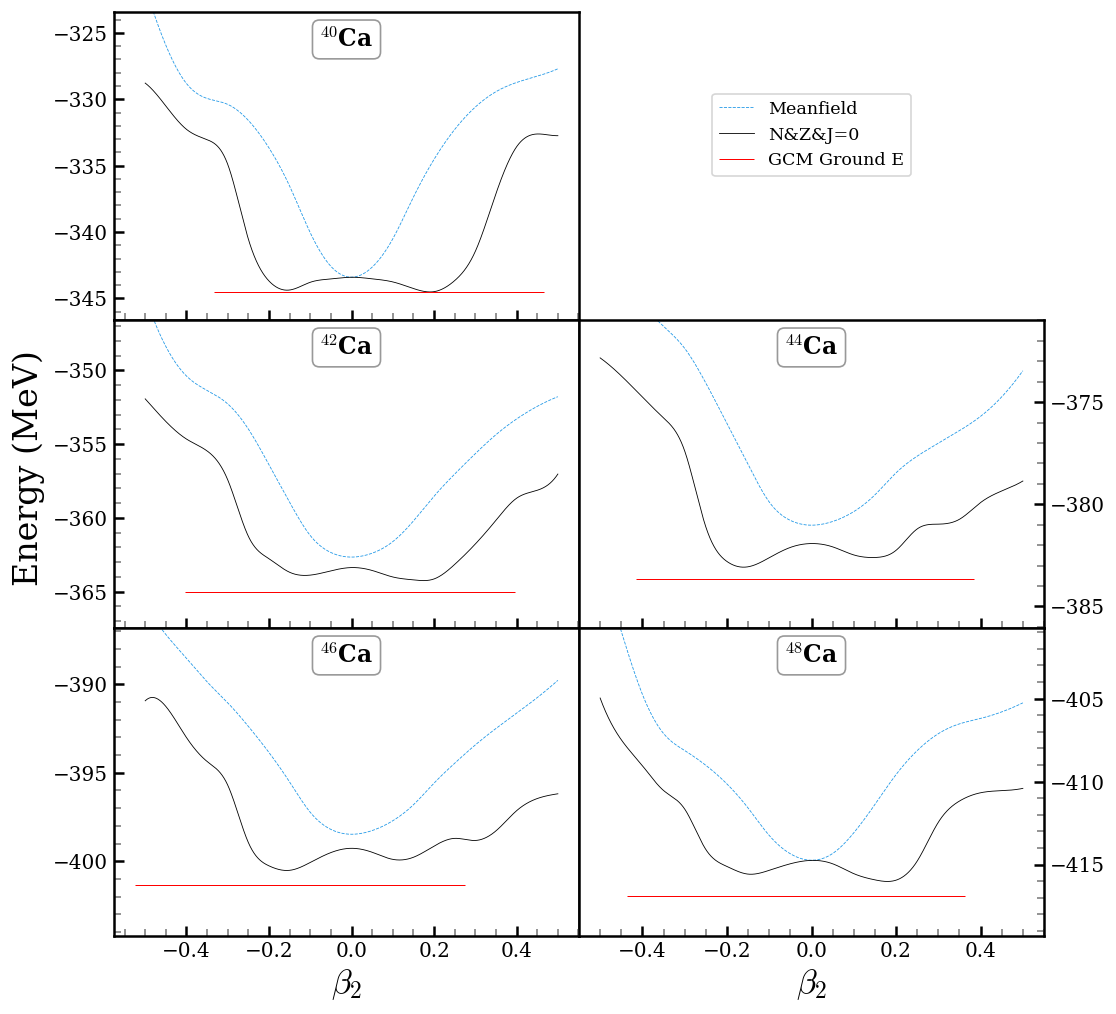

In [ ]:
from scipy.interpolate import interp1d
class DataProcessingandPlot():
    def __init__(
            self, cores, num, delete_num, palettes, 
            y_columns=['Etot', 'energy_J0', 'energy_J2', 'energy_J4', 'energy_J6'],
            labels=['Meanfield', 'N&Z&J=0', 'N&Z&J=2', 'N&Z&J=4', 'N&Z&J=6', 'GCM_energy'],
            inter_method='cubic',
            xlabel=r"$\beta_2$",
            ylabel="Energy (MeV)",
            title="Isotope chain of Ca with different J",
            ticks=None, ranges=None):
        self.cores = cores
        self.delete_num = delete_num
        # print(list(self.cores.keys())[num])
        self.df_origin = self.cores[1].df
        self.y_columns = y_columns
        self.kind = inter_method  # 使用线性插值linear，更稳定, cubic更平滑, 
        self.num_points = 10000  # 统一插值点数
        self.palettes = palettes
        self.labels    = labels
        self.xlabel   = xlabel
        self.ylabel    = ylabel
        self.title     = title
        # 刻度
        self.ticks = ticks
        self.ranges = ranges

    def interpolated_data(self, df_origin):
            

        
        # df_copy = final_df.copy()

        # 将beta2=0的行对应的列energy_J2,4,6设为NAN
        df_origin.loc[(df_origin['beta2'] >= -self.delete_num) & (df_origin['beta2'] <= self.delete_num), ['energy_J2', 'energy_J4', 'energy_J6']] = np.nan
        # print(df_copy)


        # 获取数据
        df = df_origin.copy()
        # print(df)
        x = df['beta2'].values.astype(float)

        # 设置插值参数
        


        # 创建统一的插值网格
        x_uniform = np.linspace(x.min(), x.max(), self.num_points)

        # 存储插值结果
        interpolated_data = {'beta2': x_uniform}

        # 处理每个列
        for col in self.y_columns:
            y_data = df[col].values.astype(float)
            
            # 创建非NaN掩码
            mask = ~np.isnan(y_data)
            
            # 找到连续非NaN段的边界
            diff = np.diff(mask.astype(int))
            split_indices = np.where(diff != 0)[0] + 1
            
            # 初始化插值结果数组
            y_interp = np.full(self.num_points, np.nan)
            
            # 处理每个分段
            start_indices = [0] + split_indices.tolist()
            end_indices = split_indices.tolist() + [len(y_data)]
            
            for s, e in zip(start_indices, end_indices):
                if s >= e:
                    continue
                    
                seg_x = x[s:e]
                seg_y = y_data[s:e]
                if np.all(np.isnan(seg_y)):
                    continue
                
                # 单点段直接赋值
                if len(seg_x) == 1:
                    idx = np.argmin(np.abs(x_uniform - seg_x[0]))
                    y_interp[idx] = seg_y[0]
                    continue
                    
                # 创建插值函数
                f = interp1d(seg_x, seg_y, kind=self.kind, bounds_error=False, fill_value=np.nan)
                
                # 在当前分段范围内插值
                segment_mask = (x_uniform >= seg_x.min()) & (x_uniform <= seg_x.max())
                y_interp[segment_mask] = f(x_uniform[segment_mask])
            
            # 存储插值结果
            interpolated_data[col] = y_interp
        return interpolated_data
    
    def plot_package(self, text, figsize):

        interpolated_data = self.interpolated_data(self.df_origin)
        # 创建插值后的DataFrame
        final_df = pd.DataFrame(interpolated_data)

        df_origin = self.df_origin.copy()
        df_copy = final_df.copy()

        x = df_copy['beta2'].values.astype(float)
        # y_columns = ['Etot', 'energy_J0', 'energy_J2', 'energy_J4', 'energy_J6']

        # save_path_plus = f"{save_path}/{name}_positive_beta2_energy_curve.png"

        # 绘图，beta2作为x轴，Etot，energy_J0, energy_J2,energy_J4,energy_J6作为y轴, 绘制于同一附图中。颜色和线条配置采用palettes.group6和palettes.linestyles
        plt.rcParams['text.usetex'] = True
        plt.rcParams['font.family'] = 'serif'

        # 假设你的数据框是 merged_nodio_plus
        merged = df_copy.copy()   # 建议 copy 避免 SettingWithCopyWarning

        # 颜色 / 线型
        # 1. 决定总共几条线、哪些要重点突出
        total_lines = 5
        highlight = [1]          # 第0条和第2条要最显眼（从0开始数）

        # 2. 自动获取颜色和线型（默认用蓝色系）
        colors, linestyles = palettes.auto_for_lines(
            total_lines=total_lines,
            highlight_indices=highlight,
            prefer_hue="red"       # 可以改成 "green"、"red"、"purple" 等
        )

        # colors = palettes.nature5

        # linestyles = palettes.linestyles

        fontsize = 24
        # 不加粗
        fontweight = "normal"
        # fontweight = "bold" # 不加粗单词  加粗    斜体

        plt.figure(figsize=figsize, dpi=120)
        # 遍历每条曲线
        for i, y_col in enumerate(self.y_columns):
                # 获取当前列的数值数据（注意转换为 float 避免类型错误）
                y_data = merged[y_col].astype(float).values
                # print(type(merged))
                # 绘制平滑曲线（如果需要插值）
                plt.plot(x, y_data,
                        color=colors[i % len(colors)],
                        linestyle=linestyles[i % len(linestyles)],
                        linewidth=2.4,
                        alpha=0.95,
                        label=self.labels[i])
                # print(type(df_origin))

        # x = df_origin['beta2'].values.astype(float)
        # for i, y_col in enumerate(self.y_columns):
        #         y_data = df_origin[y_col].astype(float).values
        #         # print(len(y_data))
        #         # 叠加原始数据点（黑色小圆点）
        #         plt.scatter(x, y_data,
        #                 color='black',
        #                 s=35,
        #                 edgecolor='white',
        #                 linewidth=0.8,
        #                 zorder=10,
        #                 alpha=0.9)

        plt.ylabel(self.ylabel, fontsize=fontsize, fontweight=fontweight)
        plt.xlabel(self.xlabel, fontsize=fontsize, fontweight=fontweight)
        plt.title(self.title, fontsize=fontsize, fontweight=fontweight, pad=15)

        

        plt.legend(fontsize=13, loc='best', frameon=True, shadow=True, fancybox=True)

        if text:
            plt.annotate(text, 
                xy=(0.5, 0.95), xycoords='axes fraction',
                ha='center', va='top', fontsize=14, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.8))

        # 黑色强调实验值（如果你有实验点，可在这里额外画）
        # plt.scatter(beta2_exp, Etot_exp, color='red', s=80, marker='*', zorder=20, label='Exp.')
        # print(colors)
        plt.tight_layout()

    def plot_multiple_subplots(self, num_rows:int=3, num_cols:int=3, figsize=(10, 10), 
                               sub_ax_locations_list=[(0, 0), 
                                                    (1, 0), (1, 1),
                                                    (2, 0), (2, 1)]):
        """
        num_rows: int, number of rows in the grid
        num_cols: int, number of columns in the grid
        figsize: tuple, size of the figure
        sub_ax_locations_list: list[tuples],list of tuples, each tuple represents the location of a subplot in the grid
        """
        # 创建子图网格
        fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize, dpi=120)
        axes[0, 1].axis('off')
        # print(type(axes[1][1]))
        # 确保axes 是一个二维数组
        if num_rows == 1 and num_cols == 1:
            axes = np.array([[axes]])
        elif num_rows == 1:
            # 将一维数组转换为二维数组，通过reshape方法实现， -1表示自动计算列数
            axes = axes.reshape(1, -1)
        elif num_cols == 1:
            axes = axes.reshape(-1, 1)
        
        # 第一列子图共享x轴
        for ax in axes[:, 0]:
            ax.sharex(axes[0, 0])
        
        # 第二列子图共享x轴
        for ax in axes[:, 1][:2]:
            ax.sharex(axes[0, 1])
        
        # ---------------------- 3. 调整子图间距（紧密相邻） ----------------------
        fig.subplots_adjust(
            hspace=0,   # 垂直方向无间距
            wspace=0 # 水平方向留极小间距（避免线条重叠，可根据需求调整）
        )  
        
        # ---------------------- 4. 控制y轴分辨率（刻度数量） ----------------------
        
        for ax in axes.flatten():  # 遍历所有子图（含隐藏的，需判断是否可见）
            
            if ax.get_visible():  # 仅处理可见子图

                # 限制y轴显示5个刻度（自动计算间隔，数值越小分辨率越高）
                ax.tick_params(axis='both', direction='in')
                ax.tick_params(
                                axis='both',
                                which='minor',    # 只改辅刻度
                                direction='in',   # 辅刻度也朝内
                                length=4,        # 辅刻度线更短（默认比主刻度短）
                                width=1,          # 辅刻度线更细
                                colors='gray'     # 辅刻度线颜色（可选，弱化视觉）
                            )
                import matplotlib.ticker as ticker
                # ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(n=5))
                # ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(n=5))
                
                # ax.locator_params(axis='y', nbins=6) 
        # if 1 not in (num_cols, num_rows):
        # ---------------------- 5. 右列y轴标签居右 ----------------------
        for i in range(num_rows):  # 遍历右列（列索引j=1）的所有行
            ax = axes[i, 1]
            ax.yaxis.set_label_position("right")  # 将y轴标签移到右侧
            ax.tick_params(axis='y', which='both', left=False, right=True, labelleft=False, labelright=True)  # 刻度标签也显示在右侧
            # ax.tick_params(axis='y', which='both', direction='in')


        # 遍历每个子图
        for idx, core in enumerate(self.cores):
            
            # print("运行到我了")
            # row = idx // num_cols
            # col = idx % num_cols
            row, col = sub_ax_locations_list[idx]
            # 声明row, col的类型
            row, col = int(row), int(col)
            # print("row, col: ", row, col)
            ax = axes[row, col]
            # ax.set_xlim() # 设置x轴范围
            # ax.set_ylim() # 设置y轴范围
           
                              
            # 获取当前子图的数据
            # print("core_id: ", core_id)
            # print("original_df: ", cores)
            original_df = core.df.copy()
            interpolated_data = self.interpolated_data(original_df)
            gcm_energy = core.gcm_energy
            finally_df = pd.DataFrame(interpolated_data)
            if self.ranges:
                
                max_y, min_y = self.ranges[idx]
            else:
                max_y = max(list(finally_df[self.y_columns].max()))
                min_y = min(list(finally_df[self.y_columns].min()))

            # 直接设置 y 轴范围（留一点上下边距）
            margin = (max_y - min_y) * 0.08          # 8% 边距，可调小到 0.05 或 0.1
            ax.set_ylim(min_y - margin, max_y + margin) # 设置 y 轴范围, 第一个参数控制

            # 让 matplotlib 自动决定刻度数量和位置（通常很美观）
            ax.locator_params(axis='y', nbins=5)     # 目标显示约6个主刻度，可改成5~8
            # print(max_y, min_y, engraving_degree)
            # ax.locator_params(axis='y', nbins=engraving_degree)
            ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(n=4))
            ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(n=5))
            # print(interpolated_data)

            # 1. 决定总共几条线、哪些要重点突出
            # total_lines = 5
            highlight = [1]          # 第1条要最显眼（从0开始数）
            sub_highlight = [0]


            colors, linestyles = palettes.get_all_colors_linestyles(
                                                    total=len(self.y_columns),
                                                    emphasize_indices=highlight,
                                                    sub_emphasize_indices=sub_highlight   # 可以为空
                                                )


            # 绘制插值曲线
            x = finally_df['beta2'].values.astype(float)
            # print(self.palettes.nature5,'\n', colors)
            for i, y_col in enumerate(self.y_columns):
                y_data = finally_df[y_col].astype(float).values
                
                ax.plot(x, y_data,
                        color=colors[i % len(colors)],
                        linestyle=linestyles[i % len(linestyles)],
                        linewidth=0.5,
                        alpha=1,
                        label=self.labels[i]
                        )
            # print(self.cores)
            # print(idx, self.cores[idx].NUC)
            ax.annotate(f"$^{{{self.cores[idx].NUC[0:2]}}}${self.cores[idx].NUC[2:4]}", 
                xy=(0.5, 0.95), xycoords='axes fraction',
                ha='center', va='top', fontsize=14, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.8), zorder=200)
            # 假设你想在 beta2 = 0.0 处标注这个值
            x_pos = beta2_expectation[idx]          # 你想放短线的位置
            marked_value = gcm_energy
            half_length = 0.4   # 短线左右各延伸多少（单位是 beta2）


            ax.plot(
                [x_pos - half_length, x_pos + half_length], 
                [marked_value, marked_value],
                color='red',
                linewidth=0.6,
                solid_capstyle='butt',   # 让线端平直，更像 hlines
                label=f'GCM Ground E'   # ← 这里给 label 就行了
            )
            
            # 8. 添加图例（只在某一个子图显示）
            if row == 1 and col == 1:
                ax.legend(
                fontsize=10.5,
                loc='center',
                # ncol=5,                    # 横向排列
                frameon=True,
                fancybox=True,
                shadow=False,
                bbox_to_anchor=(0.5, 1.6),  # 稍微向上一点，避免太贴底
            )
            
            if row == 2:
                # 设置x坐标，标题
                ax.set_xlabel(self.xlabel, fontsize=20, fontweight='normal')

            

        fontweight = "normal"        
        # 11. 添加全局标题和标签
        # fig.suptitle(self.title, fontsize=20, fontweight=fontweight, y=0.92) # y参数调整标题位置
        # fig.supxlabel(self.xlabel, fontsize=20, fontweight=fontweight, y=0.05)
        fig.supylabel(self.ylabel, fontsize=20, fontweight=fontweight, x=0.04)

        # 13. 调整布局
        # plt.tight_layout(rect=[0, 0, 1, 0.98]) # 为全局标题留空间

ticks = [
    [325, 330, 335, 340, 345],
    [348, 352, 356, 360, 364],
    [362, 368, 374, 380, 386],
    [388, 391, 394, 397, 400],
    [400, 404, 408, 412, 416]
]       
ranges = [
    (-325, -345),
    (-348, -366),
    (-372, -385),
    (-388, -403),
    (-402, -418)
]         
sub_ax_locations = [
(0, 0), 
(1, 0), (1, 1),
(2, 0), (2, 1)
]
y_columns=['Etot', 'energy_J0']
labels=['Meanfield', 'N&Z&J=0', 'GCM_energy']
inter_method='cubic'
xlabel=r"$\beta_2$"
ylabel="Energy (MeV)"
title="Isotope chain of Ca with different J"
palettes = TopJournalPalettes()
# 删除掉第二个元素
# if len(cores) > 5:
#     cores.pop(list(cores.keys())[1])
# print(cores['42Ca'].df)
# cores = cores_dict["11"]
dfs = cfm.classified_params_dir['Nf']["6"]
# print(cores)
corelist = []
for core in dfs:
    corelist.append(core.NUC)
    # 排序
    corelist = sorted(corelist)
# print(corelist)

corees = []
for num in corelist:
    for core in dfs:
        if core.NUC == num:
            
            corees.append(core)
# print(corees)
# cores = core_dict
beta2_expectation = [0.0658, -0.0031, -0.0147, -0.1244, -0.0362]
dpap = DataProcessingandPlot(corees, 1, 0.1, palettes, ticks=None, ranges=ranges, y_columns=y_columns, labels=labels, inter_method=inter_method, xlabel=xlabel, ylabel=ylabel, title=title)
dpap.plot_multiple_subplots(num_rows=3, num_cols=2, sub_ax_locations_list=sub_ax_locations)


In [2]:
import matplotlib.pyplot as plt
from functionboxes.topJournalPalettes import TopJournalPalettes
import pandas as pd
from functionboxes.functionbox import *
palette = TopJournalPalettes()
df_exp = pd.read_csv('/home/xizhang/datasets/charge_radii.csv')
df_exp_Ca = df_exp[(df_exp['symbol']=='Ca') & (df_exp['n']%2==0) & (df_exp['n']<30)]
# df_exp_Ca = df_exp_Ca[df_exp_Ca['a', 'radius_val']]
# 选出'a', 'radius_val'列
df_exp_Ca = df_exp_Ca[['a', 'radius_val']].rename(columns={'a':'A', 'radius_val':'Exp'})
print(df_exp_Ca)

     A     Exp
89  40  3.4776
91  42  3.5081
93  44  3.5179
95  46  3.4953
97  48  3.4771


    A       GCM  Meanfield       N&J     Exp
0  40  3.488688   3.362253  3.490147  3.4776
1  42  3.496859   3.406800  3.491615  3.5081
2  44  3.505518   3.450077  3.490748  3.5179
3  46  3.549804   3.491819  3.494265  3.4953
4  48  3.513984   3.528895  3.508900  3.4771
[3.48868775 3.49685911 3.50551803 3.54980418 3.51398353]
[3.49014685 3.4916147  3.49074791 3.49426509 3.50890026]
[3.4776 3.5081 3.5179 3.4953 3.4771]


(3.47, 3.555)

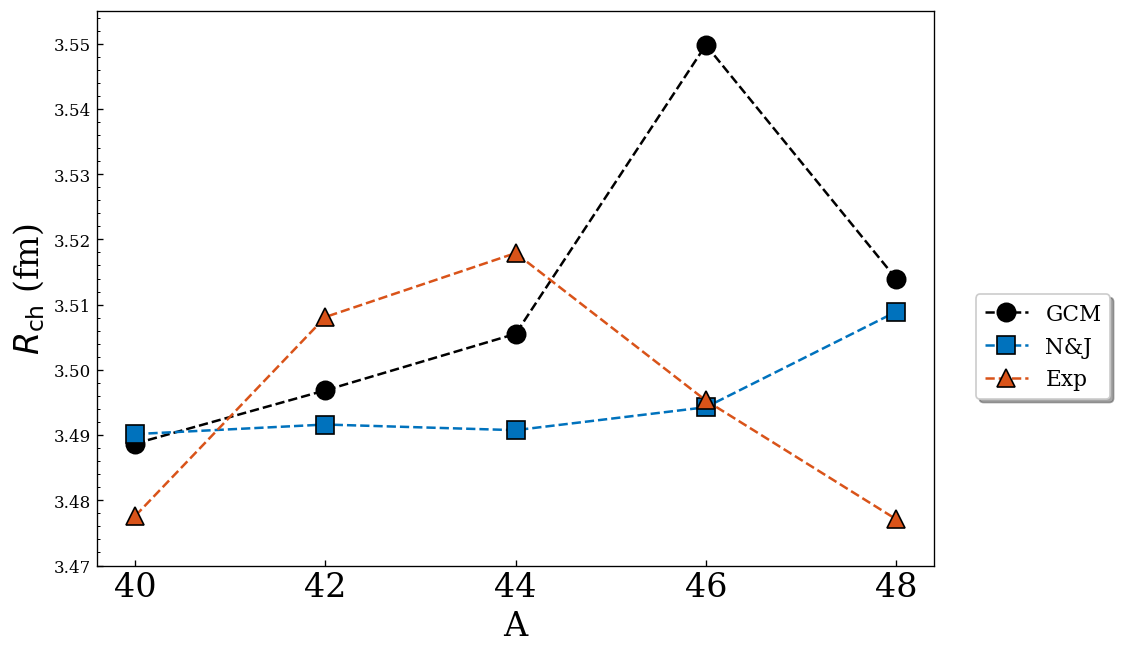

In [3]:
import pandas as pd
import numpy as np
df_create = pd.DataFrame(
    [[40,np.sqrt(3.3935**2+0.77-0.1149) ],
     [42, np.sqrt(3.4019**2+0.77-0.1149)], 
     [44,np.sqrt(3.4108**2+0.77-0.1149)], 
    [46, np.sqrt(3.4563**2+0.77-0.1149)], 
    [48,np.sqrt(3.4195**2+0.77-0.1149)]],
    columns=['A', 'GCM'])
df_create0 = pd.DataFrame(
    [[40,np.sqrt(3.360007**2-0.64+0.77-0.1149) ],
     [42, np.sqrt(3.404583**2-0.64+0.77-0.1149)], 
     [44,np.sqrt(3.447888 **2-0.64+0.77-0.1149)], 
    [46, np.sqrt(3.489656**2-0.64+0.77-0.1149)], 
    [48,np.sqrt(3.526755**2-0.64+0.77-0.1149)]],
    columns=['A', 'Meanfield'])
3.3963, 3.3950, 3.3982, 3.3990, 3.4043, 3.4210 # type: ignore
df_create1 = pd.DataFrame([
        # [40,np.sqrt(3.3963**2+0.77-0.1149) ],
    [40,np.sqrt(3.3950**2+0.77-(20)/(20)*0.1149) ],
    [42, np.sqrt(3.3982**2+0.77-(22)/(20)*0.1149)], 
    [44,np.sqrt(3.3990**2+0.77-(24)/(20)*0.1149)], 
    [46, np.sqrt(3.4043**2+0.77-(26)/(20)*0.1149)],
    [48,np.sqrt(3.4210**2+0.77-(28)/(20)*0.1149)]],
    columns=['A', 'N&J'])
df_create2 = pd.DataFrame(
    [[40, (3.47727) ],
     [42, (3.50635)], 
     [44, (3.51854)], 
    [46, (3.49515)], 
    [48, (3.47727)]],
    columns=['A', 'prl-2025'])
[3.47727,
3.50635,
3.51854,
3.49515,
3.47727] # type: ignore
# 合并为一个 df
df11 = (
    df_create
    .merge(df_create0, on='A', how='outer')
    .merge(df_create1, on='A', how='outer')
    # .merge(df_create2, on='A', how='outer')
    .merge(df_exp_Ca, on='A', how='outer')
)
print(df11)

x_name = 'A'

df_origin = df11.copy()

x = df_origin[x_name].values.astype(float)
xlabel = 'A'
ylabel = f'$R_\\text{{ch}}$ (fm)'

y_columns=[  'GCM', 'N&J', 'Exp']
labels = y_columns

text = None

# 绘图，beta2作为x轴，Etot，energy_J0, energy_J2,energy_J4,energy_J6作为y轴, 绘制于同一附图中。颜色和线条配置采用palettes.group6和palettes.linestyles
figsize = (9, 6)
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'

# 假设你的数据框是 merged_nodio_plus
# merged = df_copy.copy()   # 建议 copy 避免 SettingWithCopyWarning

# 颜色 / 线型
# 1. 决定总共几条线、哪些要重点突出
total_lines = len(y_columns)
highlight = [0, 1, 2]          # 第0条和第2条要最显眼（从0开始数）
subhighlight = []

# 2. 自动获取颜色和线型（默认用蓝色系）
colors, linestyles = palettes.get_all_colors_linestyles(total_lines, highlight,subhighlight)
markers = ['o', 's', '^', 'v', 'D', 'P', 'X', '*']

fontsize = 20
fontweight = "normal"

plt.figure(figsize=figsize, dpi=120)
# 遍历每条曲线
for i, y_col in enumerate(y_columns):
        # 获取当前列的数值数据（注意转换为 float 避免类型错误）
        y_data = df_origin[y_col].astype(float).to_numpy()
        print(y_data)
        # print(type(merged))
        # # 绘制平滑曲线（如果需要插值）
        # plt.plot(x, y_data,
        #         color=colors[i % len(colors)],
        #         linestyle=linestyles[i % len(linestyles)],
        #         linewidth=2.4,
        #         alpha=0.95,
        #         label=labels[i])
        # 刻度朝内
        plt.tick_params(axis='both', which='both', direction='in')
        
        # 设置辅刻度
        plt.minorticks_on()
        plt.tick_params(axis='x', which='minor', bottom=False, top=False)
        plt.plot(
                x, y_data,
                # 1. 颜色：保持原逻辑（循环取色）
                color=colors[i % len(colors)],
                # 2. 线型：设为无（不画线条）
                linestyle='--',  
                # 3. 标记：指定点的形状（示例用圆形，可替换为其他符号）
                marker=markers[i % len(markers)],         
                # 4. 标记大小：建议2-10（根据数据密度调整）
                markersize=11,        
                # 5. 标记填充色：可选与线条同色（或自定义）
                markerfacecolor=colors[i % len(colors)],  
                # 6. 标记边缘色：可选黑色（增强对比）
                markeredgecolor='black',  
                # 7. 边缘宽度：让点更清晰（可选）
                markeredgewidth=1,  
                # 8. 透明度：保持原逻辑（若点重叠时用）
                alpha=1,          
                # 9. 标签：保持原逻辑（用于图例）
                label=labels[i]       
            )
        # 添加虚线

        # plt.scatter(x, y_data, s=80, marker=markers[i],zorder=20, label=labels[i], color=colors[i % len(colors)], alpha=1) 
        plt.legend(fontsize=13, loc=(1.05, 0.3), frameon=True, shadow=True, fancybox=True) # 参数: frameon=True, 用于控制边框, shadow=True, 用于控制阴影, fancybox=True, 用于控制边框的形状
        
        # print(type(df_origin))
plt.xticks(np.arange(40, 50, 2), fontsize=fontsize, fontweight=fontweight)

plt.ylabel(ylabel, fontsize=fontsize, fontweight=fontweight)
plt.xlabel(xlabel, fontsize=fontsize, fontweight=fontweight)
# plt.title(title, fontsize=fontsize, fontweight=fontweight, pad=15)
plt.ylim(3.47, 3.555)



# plt.legend(fontsize=13, loc='best', frameon=True, shadow=True, fancybox=True)

# if text:
#     plt.annotate(text, 
#         xy=(0.5, 0.95), xycoords='axes fraction',
#         ha='center', va='top', fontsize=14, fontweight='bold',
#         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.8))

# # 黑色强调实验值（如果你有实验点，可在这里额外画）
# # plt.scatter(beta2_exp, Etot_exp, color='red', s=80, marker='*', zorder=20, label='Exp.')
# # print(colors)
# # plt.tight_layout()

    beta2       g1          g1sq
0    0.00  0.64693  4.185184e-01
1    0.15  0.53786  2.892934e-01
2    0.20  0.42615  1.816038e-01
3   -0.20  0.30316  9.190599e-02
4   -0.40  0.01797  3.229209e-04
5   -0.45 -0.02733  7.469289e-04
6    0.30  0.13085  1.712172e-02
7   -0.30  0.01594  2.540836e-04
8   -0.50  0.01537  2.362369e-04
9    0.45  0.00029  8.410000e-08
10   0.50 -0.00145  2.102500e-06


<Axes: xlabel='beta2', ylabel='g1sq'>

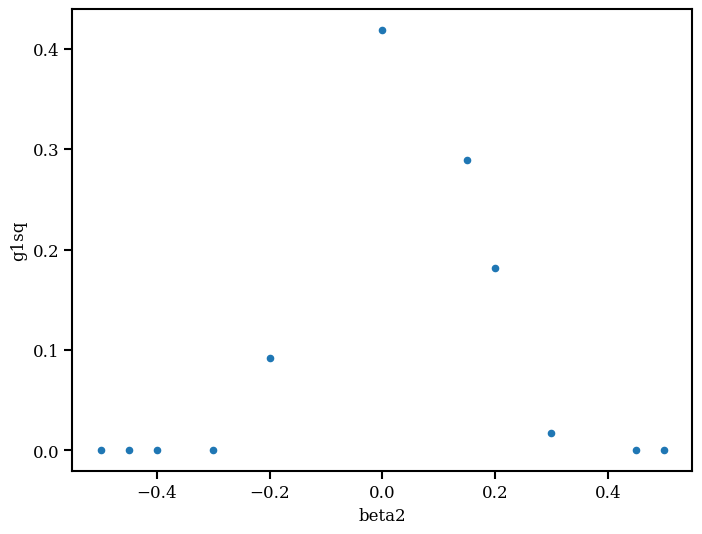

In [8]:
from io import StringIO
import pandas as pd

text40 = """ 
    K  iq   beta2   beta3   rms_R      g1         g2       g3        g4       g5         g6       g7         g8
    0  1    0.000   0.010   0.000   0.64693  -0.20152  -0.07134   0.11563  -0.07492   0.09934   0.33110   0.30221
    0  2    0.150   0.010   0.000   0.53786  -0.16206  -0.08794   0.09496  -0.06209   0.02930   0.17709  -0.15967
    0  3    0.200   0.010   0.000   0.42615   0.14099  -0.03494   0.05014  -0.05540  -0.16144  -0.62346  -0.13583
    0  4   -0.200   0.010   0.000   0.30316   0.18576   0.42409  -0.58423   0.39965   0.10075  -0.10269  -0.24441
    0  5   -0.400   0.010   0.000   0.01797  -0.16447   0.49491   0.33502  -0.38513  -0.15714  -0.18046  -0.37017
    0  6   -0.450   0.010   0.000  -0.02733   0.18196   0.20707   0.14100  -0.26383   0.12005   0.41136  -0.46264
    0  7    0.300   0.010   0.000   0.13085   0.79278  -0.28282   0.20723  -0.08365  -0.27383   0.01493   0.01319
    0  8   -0.300   0.010   0.000   0.01594   0.40602   0.49697  -0.06258  -0.12927   0.15539   0.26894   0.37751
    0  9   -0.500   0.010   0.000   0.01537  -0.06141   0.36614   0.15064  -0.16278  -0.07706  -0.30683   0.55527
    0 10    0.450   0.010   0.000   0.00029  -0.08440   0.23412   0.33152   0.60388  -0.61747   0.24294   0.00381
    0 11    0.500   0.010   0.000  -0.00145   0.11970   0.04942   0.56763   0.44152   0.65392  -0.17963  -0.05379"""
df_Ca40 = pd.read_csv(
    StringIO(text40),
    sep=r'\s+',
)[['beta2', 'g1']]

# df_Ca40.plot(x='beta2', y='g1', kind='scatter')
df_Ca40['g1sq'] = df_Ca40['g1']**2
print(df_Ca40)
df_Ca40.plot(x='beta2', y='g1sq', kind='scatter')